# DATA UNDERSTANDING — NYT COVID-19 DATA (GOOGLE COLAB) — REVISED

**Bài toán:** hỗ trợ CDC theo dõi diễn biến COVID-19 theo quận/huyện (county), đánh giá chất lượng dữ liệu và chuẩn bị cơ sở khoa học cho các bước Descriptive → Diagnostic → Predictive → Prescriptive.

Notebook này được thiết kế để chạy bằng **Google Colab → Runtime → Run all**.

### Điểm cải tiến của bản này

1. **Không hard-code California ngay từ đầu.**
2. Phân tích dữ liệu toàn nước Mỹ trước, sau đó tạo **State Profile** để đánh giá mức độ phù hợp kỹ thuật của từng bang.
3. Cho phép:
   - chọn bang thủ công; hoặc
   - để notebook tự chọn một bang đủ điều kiện dữ liệu theo tiêu chí minh bạch.
4. Coverage được tách thành:
   - **Internal coverage:** mức đầy đủ từ ngày đầu đến ngày cuối riêng của county;
   - **Study-window coverage:** mức đầy đủ so với toàn bộ cửa sổ nghiên cứu của bang.
5. Kiểm tra missing/FIPS/Unknown **cả toàn bộ dataset và riêng bang được chọn**.
6. `new_cases_7d_avg_raw` được ghi rõ là **EDA-only**, chưa phải dữ liệu sạch để Modeling.
7. Các biểu đồ có **nhận xét định lượng tự động**, không chỉ giải thích công dụng biểu đồ.

> **Lưu ý:** `cases` và `deaths` trong dữ liệu lịch sử NYT là **số tích lũy (cumulative)**, không phải số ca/tử vong mới trong ngày.


> **Bản Enhanced:** giữ nguyên các cell code cũ và kết quả đã chạy; các cell có nhãn “bổ sung” được thêm để tăng chiều sâu phân tích, trực quan hóa và nhận xét phục vụ báo cáo.


## 0. Chuẩn bị môi trường Google Colab

Notebook hỗ trợ **3 chế độ dữ liệu**:

- `GITHUB` — khuyến nghị: tự tải dữ liệu chính thức NYT.
- `UPLOAD` — upload file CSV từ máy.
- `DRIVE` — đọc dữ liệu từ Google Drive.

Mặc định notebook dùng các file county 2020–2023 để Data Understanding có đủ lịch sử nhiều năm. Việc dùng bao nhiêu năm để **train model** sẽ được quyết định ở bước sau bằng time-based validation, không quyết định chỉ vì “nhiều dữ liệu hơn”.


In [ ]:
# ============================================================
# 0.1 IMPORT THƯ VIỆN & CẤU HÌNH COLAB
# ============================================================
from pathlib import Path
import re
import warnings
import shutil
import urllib.request
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

try:
    from google.colab import files, drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Đang chạy trên Google Colab:" if IN_COLAB else "Đang chạy ngoài Google Colab:", IN_COLAB)

# =========================
# CẤU HÌNH NGUỒN DỮ LIỆU
# =========================
DATA_MODE = "GITHUB"        # "GITHUB", "UPLOAD", "DRIVE"
COUNTY_YEARS = [2020, 2021, 2022, 2023]

# Có thể để None để dùng toàn bộ thời gian có sẵn.
START_DATE = None           # Ví dụ "2020-03-01"
END_DATE = None             # Ví dụ "2023-03-23"

DRIVE_DATA_DIR = "/content/drive/MyDrive/COVID_Project/data/raw"

# =========================
# CẤU HÌNH CHỌN BANG
# =========================
# Nếu muốn tự chọn, ví dụ:
# MANUAL_TARGET_STATE = "California"
# Nếu để None, notebook tự chọn theo tiêu chí kỹ thuật bên dưới.
MANUAL_TARGET_STATE = None

# Tiêu chí AUTO chỉ đánh giá "độ phù hợp kỹ thuật của dữ liệu",
# KHÔNG phải mức độ dịch nghiêm trọng và KHÔNG phải xếp hạng y tế.
MIN_COUNTIES_FOR_AUTO = 20
MIN_MEDIAN_STUDY_COVERAGE_PCT = 95
MAX_MISSING_DEATHS_PCT = 5
MAX_MISSING_FIPS_PCT = 5

TOP_N_COUNTIES = 10

BASE_DIR = Path("/content") if IN_COLAB else Path(".")
DATA_DIR = BASE_DIR / "data" / "raw"
OUTPUT_DIR = BASE_DIR / "outputs"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEARCH_DIRS = [DATA_DIR, BASE_DIR, Path("."), Path("data/raw")]

print("DATA_MODE =", DATA_MODE)
print("COUNTY_YEARS =", COUNTY_YEARS)
print("MANUAL_TARGET_STATE =", MANUAL_TARGET_STATE)
print("DATA_DIR =", DATA_DIR)
print("OUTPUT_DIR =", OUTPUT_DIR)


Đang chạy trên Google Colab: True
DATA_MODE = GITHUB
COUNTY_YEARS = [2020, 2021, 2022, 2023]
MANUAL_TARGET_STATE = None
DATA_DIR = /content/data/raw
OUTPUT_DIR = /content/outputs


### 0.2 Nạp dữ liệu vào Colab

Ở chế độ `GITHUB`, notebook tải các file county theo năm cùng `us-states.csv` và `us.csv`.

Sau khi hoàn tất, các file raw được giữ nguyên trong `/content/data/raw/`.


In [ ]:
# ============================================================
# 0.2 CHUẨN BỊ NGUỒN DỮ LIỆU
# ============================================================
NYT_BASE = "https://raw.githubusercontent.com/nytimes/covid-19-data/master"

def download_file(url, dest):
    dest = Path(dest)
    if dest.exists() and dest.stat().st_size > 0:
        print(f"✓ Đã có: {dest.name}")
        return dest
    print(f"↓ Đang tải: {dest.name}")
    urllib.request.urlretrieve(url, dest)
    print(f"✓ Hoàn tất: {dest.name}")
    return dest

if DATA_MODE.upper() == "GITHUB":
    for year in COUNTY_YEARS:
        name = f"us-counties-{year}.csv"
        download_file(f"{NYT_BASE}/{name}", DATA_DIR / name)

    for name in ["us-states.csv", "us.csv"]:
        try:
            download_file(f"{NYT_BASE}/{name}", DATA_DIR / name)
        except Exception as e:
            print(f"⚠ Không tải được {name}: {e}")

elif DATA_MODE.upper() == "UPLOAD":
    if not IN_COLAB:
        raise RuntimeError("UPLOAD mode được thiết kế cho Google Colab.")
    print("Hãy chọn các file CSV của nhóm để upload...")
    uploaded = files.upload()
    for filename in uploaded.keys():
        src_path = Path("/content") / filename
        dest_path = DATA_DIR / filename
        if src_path.resolve() != dest_path.resolve():
            shutil.move(str(src_path), str(dest_path))
        print("✓ Đã lưu:", dest_path)

elif DATA_MODE.upper() == "DRIVE":
    if not IN_COLAB:
        raise RuntimeError("DRIVE mode được thiết kế cho Google Colab.")
    drive.mount("/content/drive")
    drive_dir = Path(DRIVE_DATA_DIR)
    if not drive_dir.exists():
        raise FileNotFoundError(f"Không tìm thấy thư mục Drive: {drive_dir}")
    SEARCH_DIRS.insert(0, drive_dir)
    print("✓ Đã thêm thư mục Drive:", drive_dir)

else:
    raise ValueError('DATA_MODE phải là "GITHUB", "UPLOAD" hoặc "DRIVE".')

print("\nCác file CSV hiện có:")
for p in sorted(DATA_DIR.glob("*.csv")):
    print(f" - {p.name}: {p.stat().st_size / 1024**2:.2f} MB")


✓ Đã có: us-counties-2020.csv
✓ Đã có: us-counties-2021.csv
✓ Đã có: us-counties-2022.csv
✓ Đã có: us-counties-2023.csv
✓ Đã có: us-states.csv
✓ Đã có: us.csv

Các file CSV hiện có:
 - us-counties-2020.csv: 34.21 MB
 - us-counties-2021.csv: 47.98 MB
 - us-counties-2022.csv: 48.83 MB
 - us-counties-2023.csv: 11.01 MB
 - us-states.csv: 2.11 MB
 - us.csv: 0.03 MB


## 1. Nạp dữ liệu và xác định nguồn thực tế

- County-level data là nguồn chính cho bài toán quận/huyện.
- `us-states.csv` và `us.csv` chỉ dùng để tham chiếu/đối chiếu.
- Nếu có file county theo năm, notebook tự ghép thành một bảng nhiều năm.


In [ ]:
def existing_files(pattern):
    found = []
    for d in SEARCH_DIRS:
        d = Path(d)
        if d.exists():
            found.extend(d.glob(pattern))
    unique, seen = [], set()
    for p in found:
        key = str(p.resolve())
        if key not in seen:
            seen.add(key)
            unique.append(p)
    return sorted(unique)

def find_first(name):
    for d in SEARCH_DIRS:
        p = Path(d) / name
        if p.exists():
            return p
    return None

def read_csv_safe(path):
    return pd.read_csv(path, dtype={"fips": "string"}, low_memory=False)

annual_county_files = existing_files("us-counties-20*.csv")
annual_county_files = [p for p in annual_county_files if "recent" not in p.name.lower()]

if annual_county_files:
    print("Các file county theo năm được tìm thấy:")
    for p in annual_county_files:
        print(" -", p.name)
    df_county_raw = pd.concat(
        [read_csv_safe(p) for p in annual_county_files],
        ignore_index=True
    )
    COUNTY_SOURCE = " + ".join(p.name for p in annual_county_files)
    COUNTY_MODE = "annual_files"
else:
    county_path = find_first("us-counties.csv")
    if county_path is None:
        raise FileNotFoundError("Không tìm thấy dữ liệu county.")
    df_county_raw = read_csv_safe(county_path)
    COUNTY_SOURCE = county_path.name
    COUNTY_MODE = "legacy_single_file"

state_path = find_first("us-states.csv")
us_path = find_first("us.csv")
df_states_raw = read_csv_safe(state_path) if state_path else None
df_us_raw = read_csv_safe(us_path) if us_path else None

print("\nNguồn county:", COUNTY_SOURCE)
print("Số dòng county:", f"{len(df_county_raw):,}")
print("Có us-states.csv:", df_states_raw is not None)
print("Có us.csv:", df_us_raw is not None)


Các file county theo năm được tìm thấy:
 - us-counties-2020.csv
 - us-counties-2021.csv
 - us-counties-2022.csv
 - us-counties-2023.csv

Nguồn county: us-counties-2020.csv + us-counties-2021.csv + us-counties-2022.csv + us-counties-2023.csv
Số dòng county: 3,525,161
Có us-states.csv: True
Có us.csv: True


### Nhận xét kết quả nạp dữ liệu

Notebook đã ghép dữ liệu county của **2020, 2021, 2022 và 2023** thành một nguồn county-level thống nhất với **3.525.161 quan sát và 6 biến**. Việc dùng nhiều năm ở bước Data Understanding là hợp lý vì mục tiêu hiện tại là hiểu phạm vi, chất lượng và sự thay đổi của dữ liệu theo thời gian; nó **chưa đồng nghĩa** toàn bộ giai đoạn này sẽ được dùng để train model.

`us-states.csv` và `us.csv` được giữ làm nguồn đối chiếu. Đây là điểm tốt vì có thể kiểm tra tính nhất quán giữa cấp county, cấp bang và toàn quốc thay vì chỉ tin vào một bảng duy nhất.


## 2. Kiểm tra cấu trúc tổng quát

### Câu hỏi cần trả lời

- Dataset có bao nhiêu dòng/cột?
- Một dòng đại diện cho gì?
- Có đúng các biến kỳ vọng không?
- Kiểu dữ liệu hiện tại có phù hợp không?

**Đơn vị quan sát:** một record biểu diễn tình hình COVID-19 của **một county trong một ngày cụ thể**.


In [ ]:
EXPECTED_COUNTY_COLUMNS = ["date", "county", "state", "fips", "cases", "deaths"]

print("Shape:", df_county_raw.shape)
print("Columns:", df_county_raw.columns.tolist())
print("\nDtypes:")
display(df_county_raw.dtypes.to_frame("dtype"))

missing_expected = [c for c in EXPECTED_COUNTY_COLUMNS if c not in df_county_raw.columns]
if missing_expected:
    raise ValueError(f"Thiếu các cột bắt buộc: {missing_expected}")

display(df_county_raw.head())


Shape: (3525161, 6)
Columns: ['date', 'county', 'state', 'fips', 'cases', 'deaths']

Dtypes:


,dtype
date,object
county,object
state,object
fips,string[python]
cases,int64
deaths,float64


,date,county,state,fips,cases,deaths
0,2020-01-21,Snohomish,Washington,53061,1,0.00
1,2020-01-22,Snohomish,Washington,53061,1,0.00
2,2020-01-23,Snohomish,Washington,53061,1,0.00
3,2020-01-24,Cook,Illinois,17031,1,0.00
4,2020-01-24,Snohomish,Washington,53061,1,0.00


### Data Dictionary

| Biến | Loại thống kê | Vai trò | Ý nghĩa |
|---|---|---|---|
| `date` | Temporal | Time key | Ngày ghi nhận |
| `county` | Categorical | Geographic label | Tên county |
| `state` | Categorical | Geographic label | Bang |
| `fips` | Identifier | Geographic ID | Mã FIPS; không phải đại lượng số |
| `cases` | Quantitative | Measurement | Tổng ca **tích lũy** |
| `deaths` | Quantitative | Measurement | Tổng tử vong **tích lũy** |

> `fips` phải được xem như **ID/string**, không dùng như một biến số liên tục.


## 3. Chuẩn hóa ngày và đánh giá phạm vi thời gian/địa lý toàn nước Mỹ

Không lọc bang/năm ngay. Trước hết cần biết nguồn dữ liệu thật sự bao phủ khoảng nào.


In [ ]:
df_county = df_county_raw.copy()
df_county["date"] = pd.to_datetime(df_county["date"], errors="coerce")

if START_DATE is not None:
    df_county = df_county[df_county["date"] >= pd.Timestamp(START_DATE)].copy()
if END_DATE is not None:
    df_county = df_county[df_county["date"] <= pd.Timestamp(END_DATE)].copy()

print("Ngày nhỏ nhất:", df_county["date"].min())
print("Ngày lớn nhất :", df_county["date"].max())
print("Số bang/territory:", df_county["state"].nunique(dropna=True))
print("Số tổ hợp state-county:", df_county[["state", "county"]].drop_duplicates().shape[0])
print("Số năm:", sorted(df_county["date"].dropna().dt.year.unique().tolist()))

for name, ref in [("us-states.csv", df_states_raw), ("us.csv", df_us_raw)]:
    if ref is not None and "date" in ref.columns:
        temp = ref.copy()
        temp["date"] = pd.to_datetime(temp["date"], errors="coerce")
        print(f"{name}: shape={temp.shape}, range={temp['date'].min().date()} -> {temp['date'].max().date()}")


Ngày nhỏ nhất: 2020-01-21 00:00:00
Ngày lớn nhất : 2023-03-23 00:00:00
Số bang/territory: 56
Số tổ hợp state-county: 3278
Số năm: [2020, 2021, 2022, 2023]
us-states.csv: shape=(61942, 5), range=2020-01-21 -> 2023-03-23
us.csv: shape=(1158, 3), range=2020-01-21 -> 2023-03-23


## 4. Đánh giá chất lượng dữ liệu toàn bộ nguồn

Ở bước Data Understanding, ta **phát hiện và mô tả vấn đề**, chưa tự động sửa.

Kiểm tra:

- missing values;
- duplicate county–ngày;
- `Unknown`;
- thiếu FIPS;
- ngày không hợp lệ.


MISSING VALUES — TOÀN BỘ NGUỒN


,missing_count,missing_percent
deaths,82097,2.33
fips,35156,1.00
county,0,0.00
date,0,0.00
state,0,0.00
cases,0,0.00


Số dòng tham gia duplicate theo ['date', 'state', 'county']: 0
Số dòng county='Unknown': 31,937
Số dòng thiếu FIPS: 35,156
Số ngày không hợp lệ (NaT): 0


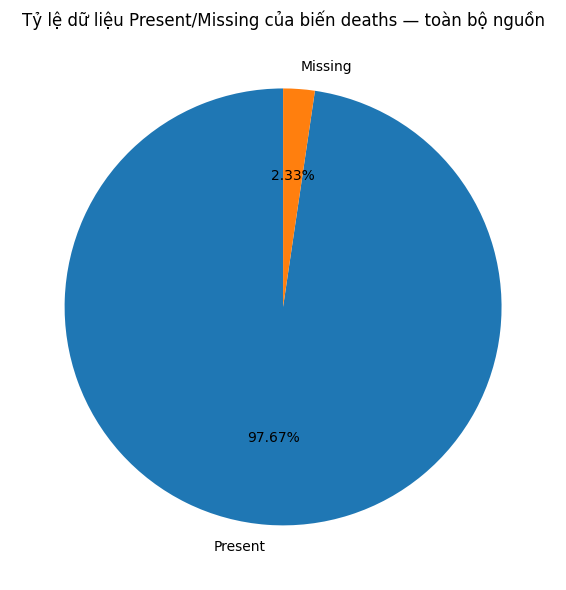

Nhận xét: deaths có 82,097 giá trị thiếu trên 3,525,161 dòng (2.33%).


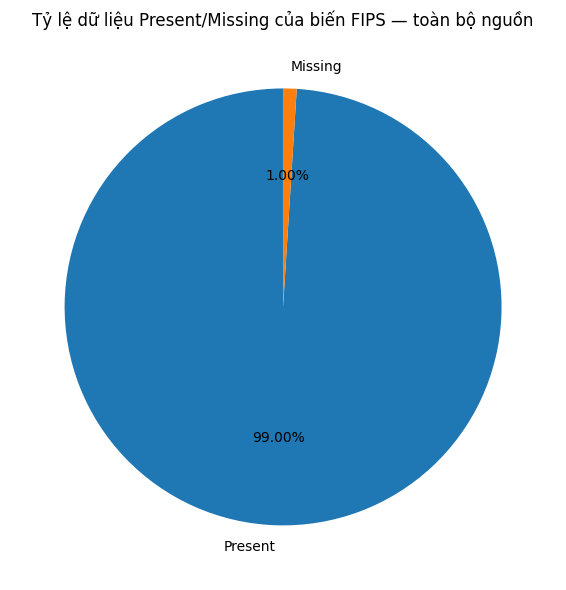

Nhận xét: FIPS có 35,156 giá trị thiếu trên 3,525,161 dòng (1.00%). Cần kiểm tra các dòng này có thuộc nhãn địa lý kỹ thuật hay không.


In [ ]:
global_missing_table = pd.DataFrame({
    "missing_count": df_county.isna().sum(),
    "missing_percent": (df_county.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)

print("MISSING VALUES — TOÀN BỘ NGUỒN")
display(global_missing_table)

key_cols = ["date", "state", "county"]
dup_count = df_county.duplicated(subset=key_cols, keep=False).sum()

unknown_global_mask = (
    df_county["county"].astype("string")
    .str.strip().str.lower().eq("unknown")
)

print(f"Số dòng tham gia duplicate theo {key_cols}: {dup_count:,}")
print("Số dòng county='Unknown':", f"{int(unknown_global_mask.sum()):,}")
print("Số dòng thiếu FIPS:", f"{int(df_county['fips'].isna().sum()):,}")
print("Số ngày không hợp lệ (NaT):", int(df_county["date"].isna().sum()))

# Pie chart 1 — deaths: Present vs Missing
death_missing = int(df_county["deaths"].isna().sum())
death_present = int(df_county["deaths"].notna().sum())

plt.figure(figsize=(6, 6))
plt.pie(
    [death_present, death_missing],
    labels=["Present", "Missing"],
    autopct="%1.2f%%",
    startangle=90
)
plt.title("Tỷ lệ dữ liệu Present/Missing của biến deaths — toàn bộ nguồn")
plt.tight_layout()
plt.show()

print(
    f"Nhận xét: deaths có {death_missing:,} giá trị thiếu trên {len(df_county):,} dòng "
    f"({death_missing/len(df_county)*100:.2f}%)."
)

# Pie chart 2 — FIPS: Present vs Missing
fips_missing = int(df_county["fips"].isna().sum())
fips_present = int(df_county["fips"].notna().sum())

plt.figure(figsize=(6, 6))
plt.pie(
    [fips_present, fips_missing],
    labels=["Present", "Missing"],
    autopct="%1.2f%%",
    startangle=90
)
plt.title("Tỷ lệ dữ liệu Present/Missing của biến FIPS — toàn bộ nguồn")
plt.tight_layout()
plt.show()

print(
    f"Nhận xét: FIPS có {fips_missing:,} giá trị thiếu trên {len(df_county):,} dòng "
    f"({fips_missing/len(df_county)*100:.2f}%). "
    "Cần kiểm tra các dòng này có thuộc nhãn địa lý kỹ thuật hay không."
)



### Nhận xét chất lượng dữ liệu toàn bộ nguồn

Kết quả hiện tại cho thấy `deaths` thiếu khoảng **2,33%** và `fips` thiếu khoảng **1,00%**, trong khi `date`, `county`, `state` và `cases` không có missing. Như vậy dữ liệu nhìn chung có độ đầy đủ cao, nhưng missing không nên được xử lý bằng `fillna(0)` vì **thiếu dữ liệu không đồng nghĩa với giá trị bằng 0**.

Ở bước tiếp theo cần xem missing tập trung ở bang/county nào và có liên quan đến các nhãn kỹ thuật như `Unknown` hay không. Nếu missing tập trung vào một nhóm cụ thể, xử lý theo ngữ cảnh sẽ hợp lý hơn xóa toàn bộ hàng.


## 5. State Profile — đánh giá các bang trước khi chọn phạm vi nghiên cứu

Đây là thay đổi quan trọng so với phiên bản cũ.

Notebook **không chọn California trước**. Thay vào đó, với từng bang ta tính:

- số county;
- số record;
- thời gian quan sát;
- tỷ lệ missing `deaths`;
- tỷ lệ missing FIPS;
- tỷ lệ `Unknown`;
- median **internal coverage** của các county;
- median **state-window coverage** của các county.

### Quy tắc AUTO

Một bang được xem là **đủ điều kiện kỹ thuật** nếu thỏa các ngưỡng cấu hình ở đầu notebook. Nếu có nhiều bang thỏa, notebook ưu tiên bang có:

1. nhiều county hơn;
2. sau đó coverage cao hơn;
3. sau đó missing thấp hơn.

> Đây **không phải xếp hạng mức độ dịch**, chỉ là cách chọn một phạm vi có dữ liệu đủ phong phú và đầy đủ để minh họa phân tích sâu. Bạn luôn có thể đặt `MANUAL_TARGET_STATE`.


In [ ]:
# Loại Unknown chỉ trong phép tính coverage theo county thật;
# vẫn giữ Unknown trong dataset để đánh giá chất lượng.
profile_geo = df_county[
    df_county["date"].notna() &
    df_county["state"].notna() &
    df_county["county"].notna() &
    ~unknown_global_mask
].copy()

# Cửa sổ quan sát riêng của từng bang
state_windows = (
    profile_geo.groupby("state", as_index=False)
    .agg(
        state_start=("date", "min"),
        state_end=("date", "max")
    )
)
state_windows["state_window_days"] = (
    state_windows["state_end"] - state_windows["state_start"]
).dt.days + 1

# Coverage từng county
county_profile = (
    profile_geo.groupby(["state", "county"], as_index=False)
    .agg(
        first_date=("date", "min"),
        last_date=("date", "max"),
        n_records=("date", "size"),
        n_unique_dates=("date", "nunique")
    )
    .merge(state_windows, on="state", how="left")
)

county_profile["internal_days"] = (
    county_profile["last_date"] - county_profile["first_date"]
).dt.days + 1

county_profile["internal_coverage_pct"] = (
    county_profile["n_unique_dates"] /
    county_profile["internal_days"] * 100
).round(2)

county_profile["state_window_coverage_pct"] = (
    county_profile["n_unique_dates"] /
    county_profile["state_window_days"] * 100
).round(2)

# Missing / Unknown theo bang
state_quality = (
    df_county.groupby("state", as_index=False)
    .agg(
        n_rows=("date", "size"),
        n_counties_labels=("county", "nunique"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        missing_deaths=("deaths", lambda s: s.isna().sum()),
        missing_fips=("fips", lambda s: s.isna().sum()),
        unknown_rows=("county", lambda s: s.astype("string").str.strip().str.lower().eq("unknown").sum())
    )
)

state_quality["missing_deaths_pct"] = (
    state_quality["missing_deaths"] / state_quality["n_rows"] * 100
).round(2)
state_quality["missing_fips_pct"] = (
    state_quality["missing_fips"] / state_quality["n_rows"] * 100
).round(2)
state_quality["unknown_pct"] = (
    state_quality["unknown_rows"] / state_quality["n_rows"] * 100
).round(2)

coverage_by_state = (
    county_profile.groupby("state", as_index=False)
    .agg(
        n_counties=("county", "nunique"),
        median_internal_coverage_pct=("internal_coverage_pct", "median"),
        min_internal_coverage_pct=("internal_coverage_pct", "min"),
        median_study_coverage_pct=("state_window_coverage_pct", "median"),
        min_study_coverage_pct=("state_window_coverage_pct", "min")
    )
)

state_profile = state_quality.merge(coverage_by_state, on="state", how="left")

state_profile["eligible_auto"] = (
    (state_profile["n_counties"] >= MIN_COUNTIES_FOR_AUTO) &
    (state_profile["median_study_coverage_pct"] >= MIN_MEDIAN_STUDY_COVERAGE_PCT) &
    (state_profile["missing_deaths_pct"] <= MAX_MISSING_DEATHS_PCT) &
    (state_profile["missing_fips_pct"] <= MAX_MISSING_FIPS_PCT)
)

display_cols = [
    "state", "n_rows", "n_counties",
    "start_date", "end_date",
    "missing_deaths_pct", "missing_fips_pct", "unknown_pct",
    "median_internal_coverage_pct", "median_study_coverage_pct",
    "eligible_auto"
]

state_profile_view = state_profile.sort_values(
    ["eligible_auto", "n_counties", "median_study_coverage_pct", "missing_deaths_pct"],
    ascending=[False, False, False, True]
)

print("TOP STATE PROFILE (ưu tiên điều kiện kỹ thuật, không phải mức độ dịch):")
display(state_profile_view[display_cols].head(20))

# Chọn bang
available_states = set(state_profile["state"].dropna())

if MANUAL_TARGET_STATE is not None:
    if MANUAL_TARGET_STATE not in available_states:
        raise ValueError(
            f"Không tìm thấy bang '{MANUAL_TARGET_STATE}'. "
            f"Hãy kiểm tra chính tả hoặc để MANUAL_TARGET_STATE = None."
        )
    TARGET_STATE = MANUAL_TARGET_STATE
    STATE_SELECTION_REASON = "manual"
else:
    eligible = state_profile[state_profile["eligible_auto"]].copy()
    if len(eligible) > 0:
        chosen = eligible.sort_values(
            ["n_counties", "median_study_coverage_pct", "missing_deaths_pct", "missing_fips_pct"],
            ascending=[False, False, True, True]
        ).iloc[0]
        TARGET_STATE = chosen["state"]
        STATE_SELECTION_REASON = "auto_eligible"
    else:
        fallback = state_profile[state_profile["n_counties"] >= MIN_COUNTIES_FOR_AUTO].copy()
        if len(fallback) == 0:
            fallback = state_profile.copy()
        chosen = fallback.sort_values(
            ["median_study_coverage_pct", "n_counties", "missing_deaths_pct"],
            ascending=[False, False, True]
        ).iloc[0]
        TARGET_STATE = chosen["state"]
        STATE_SELECTION_REASON = "auto_fallback"

print("\nBang được chọn cho phân tích sâu:", TARGET_STATE)
print("Cách chọn:", STATE_SELECTION_REASON)
print("Lưu ý: đây là lựa chọn theo tính phù hợp kỹ thuật dữ liệu, không phải xếp hạng nguy cơ dịch.")

state_profile.to_csv(OUTPUT_DIR / "state_profile.csv", index=False)
county_profile.to_csv(OUTPUT_DIR / "county_profile_all_states.csv", index=False)


TOP STATE PROFILE (ưu tiên điều kiện kỹ thuật, không phải mức độ dịch):


,state,n_rows,n_counties,start_date,end_date,missing_deaths_pct,missing_fips_pct,unknown_pct,median_internal_coverage_pct,median_study_coverage_pct,eligible_auto
47,Texas,273458,255.00,2020-02-12,2023-03-23,0.00,0.04,0.04,100.00,95.69,True
11,Georgia,175129,159.00,2020-03-02,2023-03-23,0.00,0.63,0.63,100.00,98.03,True
51,Virginia,144967,133.00,2020-03-07,2023-03-23,0.00,0.08,0.08,100.00,98.20,True
19,Kentucky,130328,120.00,2020-03-06,2023-03-23,0.00,0.09,0.09,100.00,97.80,True
27,Missouri,126338,117.00,2020-03-07,2023-03-23,0.00,1.69,0.03,100.00,97.93,True
18,Kansas,112288,105.00,2020-03-07,2023-03-23,0.00,0.24,0.24,100.00,97.30,True
35,North Carolina,109209,100.00,2020-03-03,2023-03-23,0.00,0.00,0.00,100.00,98.03,True
17,Iowa,108426,99.00,2020-03-08,2023-03-23,0.00,0.93,0.93,100.00,98.20,True
46,Tennessee,104863,95.00,2020-03-05,2023-03-23,0.00,0.98,0.98,100.00,98.29,True
16,Indiana,101101,92.00,2020-03-06,2023-03-23,0.00,0.33,0.33,100.00,98.38,True



Bang được chọn cho phân tích sâu: Texas
Cách chọn: auto_eligible
Lưu ý: đây là lựa chọn theo tính phù hợp kỹ thuật dữ liệu, không phải xếp hạng nguy cơ dịch.


### Nhận xét State Profile và việc chọn bang

Kết quả notebook hiện tại chọn **Texas** theo chế độ `auto_eligible`. Lý do kỹ thuật là Texas thuộc nhóm vượt qua các ngưỡng về coverage/missing và có số lượng county labels lớn nhất trong nhóm đủ điều kiện.

Điều này **không có nghĩa Texas là bang có dịch nghiêm trọng nhất hoặc “tốt nhất” tuyệt đối**. Đây chỉ là một lựa chọn để có phạm vi county-level đủ lớn và đủ dữ liệu cho phân tích sâu. Khi viết báo cáo nên diễn đạt theo hướng **data suitability**, không diễn giải thành xếp hạng dịch tễ.


### 5.1 Trực quan hóa State Profile

Ba góc nhìn bổ sung:

1. số lượng county labels theo bang;
2. median study-window coverage;
3. quan hệ giữa quy mô số county và coverage.

Các biểu đồ này giúp chứng minh lựa chọn phạm vi bằng dữ liệu thay vì chọn bang cảm tính.


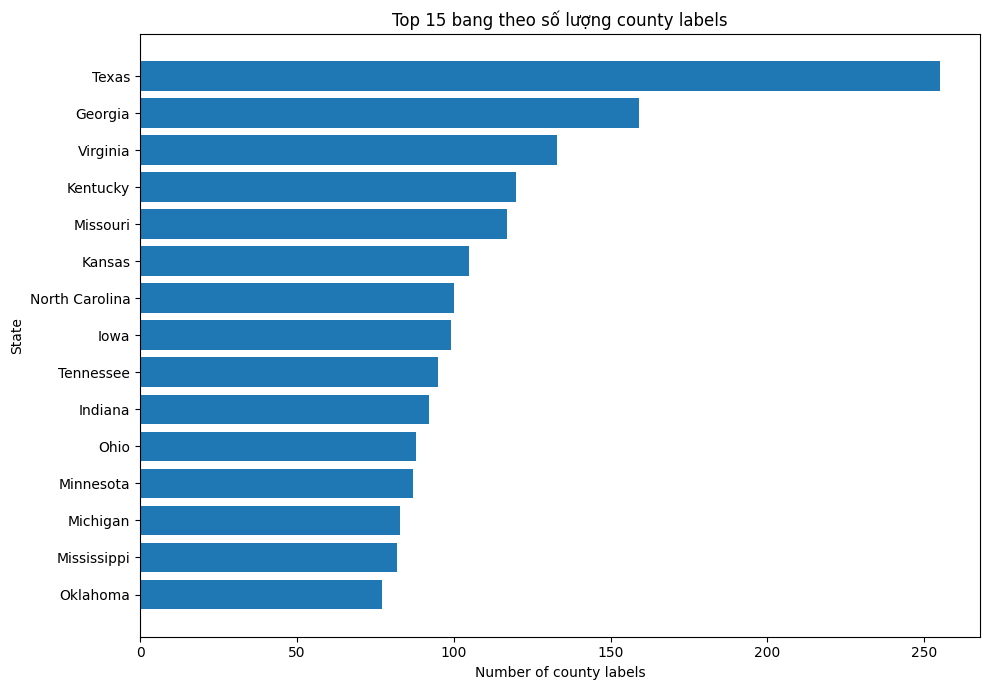

Nhận xét: trong nhóm hiển thị, Texas có số county labels lớn nhất (255). Số label chưa chắc bằng số county thực vì có thể tồn tại nhãn kỹ thuật như Unknown/Pending County Assignment.


In [ ]:
# Top 15 bang theo số county labels
top_state_counties = (
    state_profile_view[["state", "n_counties"]]
    .dropna()
    .head(15)
    .sort_values("n_counties")
)

plt.figure(figsize=(10, 7))
plt.barh(top_state_counties["state"], top_state_counties["n_counties"])
plt.title("Top 15 bang theo số lượng county labels")
plt.xlabel("Number of county labels")
plt.ylabel("State")
plt.tight_layout()
plt.show()

top_row = top_state_counties.iloc[-1]
print(
    f"Nhận xét: trong nhóm hiển thị, {top_row['state']} có số county labels lớn nhất "
    f"({int(top_row['n_counties'])}). Số label chưa chắc bằng số county thực vì có thể "
    "tồn tại nhãn kỹ thuật như Unknown/Pending County Assignment."
)


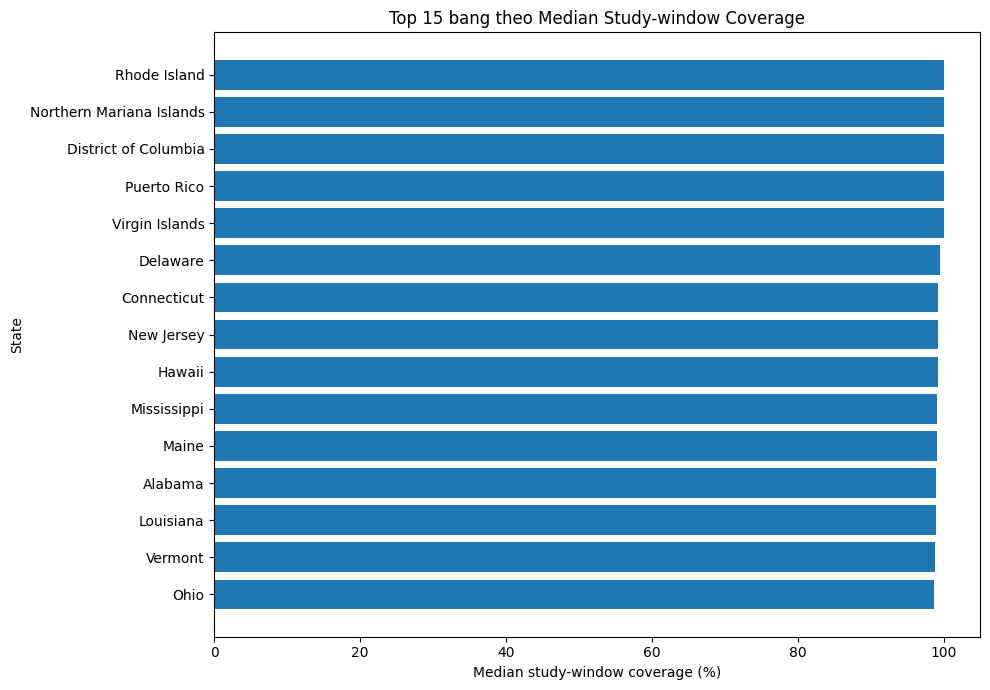

Nhận xét: median coverage cao nhất trong nhóm hiển thị là 100.00%. Coverage cao giúp giảm rủi ro chuỗi thời gian bị đứt quãng.


In [ ]:
# Top 15 bang theo median study-window coverage
coverage_states = (
    state_profile[
        ["state", "median_study_coverage_pct", "eligible_auto"]
    ]
    .dropna()
    .sort_values("median_study_coverage_pct", ascending=False)
    .head(15)
    .sort_values("median_study_coverage_pct")
)

plt.figure(figsize=(10, 7))
plt.barh(
    coverage_states["state"],
    coverage_states["median_study_coverage_pct"]
)
plt.title("Top 15 bang theo Median Study-window Coverage")
plt.xlabel("Median study-window coverage (%)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

print(
    f"Nhận xét: median coverage cao nhất trong nhóm hiển thị là "
    f"{coverage_states['median_study_coverage_pct'].max():.2f}%. "
    "Coverage cao giúp giảm rủi ro chuỗi thời gian bị đứt quãng."
)


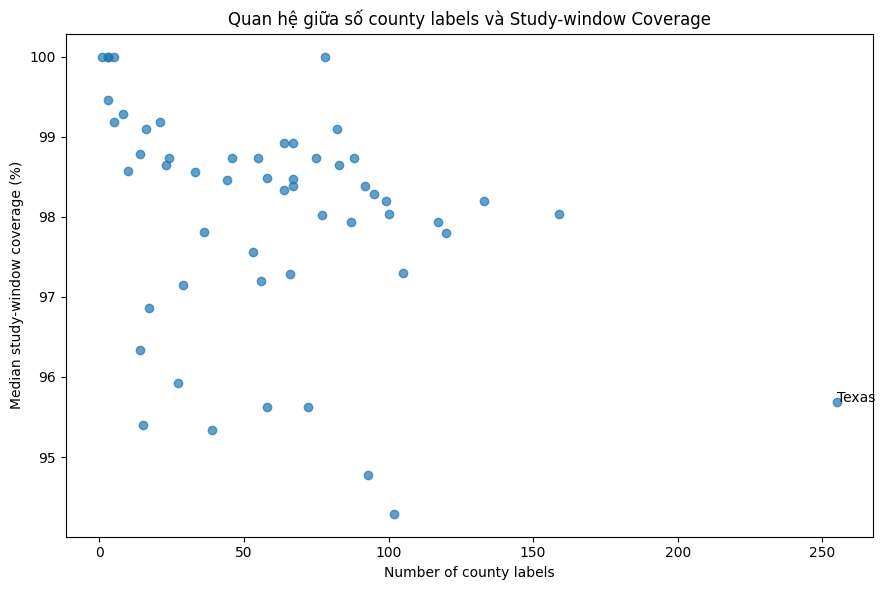

Nhận xét: biểu đồ giúp kiểm tra trade-off giữa quy mô phạm vi và độ đầy đủ dữ liệu. Texas được đánh dấu để minh họa vị trí của phạm vi được chọn.


In [ ]:
# Scatter — số county vs median coverage
plot_state = state_profile.dropna(
    subset=["n_counties", "median_study_coverage_pct"]
).copy()

plt.figure(figsize=(9, 6))
plt.scatter(
    plot_state["n_counties"],
    plot_state["median_study_coverage_pct"],
    alpha=0.7
)
plt.title("Quan hệ giữa số county labels và Study-window Coverage")
plt.xlabel("Number of county labels")
plt.ylabel("Median study-window coverage (%)")

selected_row = plot_state[plot_state["state"].eq(TARGET_STATE)]
if not selected_row.empty:
    x = selected_row["n_counties"].iloc[0]
    y = selected_row["median_study_coverage_pct"].iloc[0]
    plt.annotate(TARGET_STATE, (x, y))

plt.tight_layout()
plt.show()

print(
    "Nhận xét: biểu đồ giúp kiểm tra trade-off giữa quy mô phạm vi và độ đầy đủ dữ liệu. "
    f"{TARGET_STATE} được đánh dấu để minh họa vị trí của phạm vi được chọn."
)


## 6. Tạo phạm vi phân tích sâu và kiểm tra chất lượng riêng của bang được chọn

Sau bước State Profile, notebook mới tạo `df_focus`.

Ở đây cần kiểm tra lại missing, FIPS và `Unknown` **riêng trong phạm vi nghiên cứu**, vì chất lượng toàn nước Mỹ không đại diện cho từng bang.


In [ ]:
df_focus = df_county[df_county["state"].eq(TARGET_STATE)].copy()

print(f"Phạm vi phân tích sâu: {TARGET_STATE}")
print("Shape:", df_focus.shape)
print("Từ:", df_focus["date"].min(), "đến:", df_focus["date"].max())
print("Số county labels:", df_focus["county"].nunique(dropna=True))
print("Số năm:", sorted(df_focus["date"].dropna().dt.year.unique().tolist()))

focus_missing_table = pd.DataFrame({
    "missing_count": df_focus.isna().sum(),
    "missing_percent": (df_focus.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)

focus_unknown_mask = (
    df_focus["county"].astype("string")
    .str.strip().str.lower().eq("unknown")
)

print("\nMISSING VALUES — RIÊNG BANG ĐƯỢC CHỌN")
display(focus_missing_table)
print("Unknown rows:", f"{int(focus_unknown_mask.sum()):,}")
print("Missing FIPS:", f"{int(df_focus['fips'].isna().sum()):,}")

display(df_focus.head())


Phạm vi phân tích sâu: Texas
Shape: (273458, 6)
Từ: 2020-02-12 00:00:00 đến: 2023-03-23 00:00:00
Số county labels: 256
Số năm: [2020, 2021, 2022, 2023]

MISSING VALUES — RIÊNG BANG ĐƯỢC CHỌN


,missing_count,missing_percent
fips,119,0.04
date,0,0.00
county,0,0.00
state,0,0.00
cases,0,0.00
deaths,0,0.00


Unknown rows: 119
Missing FIPS: 119


,date,county,state,fips,cases,deaths
143,2020-02-12,Bexar,Texas,48029,1,0.00
154,2020-02-13,Bexar,Texas,48029,2,0.00
165,2020-02-14,Bexar,Texas,48029,2,0.00
176,2020-02-15,Bexar,Texas,48029,2,0.00
187,2020-02-16,Bexar,Texas,48029,2,0.00


### Nhận xét chất lượng dữ liệu riêng bang được chọn

Trong kết quả hiện tại, Texas có **273.458 dòng** và **256 county labels**. Riêng FIPS chỉ thiếu **119 dòng (~0,04%)**, còn các biến chính khác không thiếu. Đồng thời số dòng `Unknown` cũng là **119**, gợi ý mạnh rằng missing FIPS tập trung ở nhóm địa lý không xác định thay vì phân tán ngẫu nhiên trên toàn bộ county.

Đây là tín hiệu tốt về chất lượng dữ liệu, nhưng `Unknown` và các nhãn kỹ thuật khác không nên được coi như county thật khi xếp hạng, train model hoặc phân bổ nguồn lực.


### 6.1 Audit các nhãn county kỹ thuật

Ngoài `Unknown`, dữ liệu thực tế còn xuất hiện nhãn như **`Pending County Assignment`**. Notebook gốc chỉ loại `Unknown` trong một số phân tích, vì vậy phần bổ sung này tạo một mask riêng cho các label kỹ thuật mà **không sửa hoặc xóa dữ liệu raw**.

`df_focus_analysis` sẽ được dùng cho các biểu đồ bổ sung; `df_focus` nguyên bản vẫn được giữ nguyên.


In [ ]:
# Audit technical / pseudo-county labels
TECHNICAL_COUNTY_LABELS = {
    "unknown",
    "pending county assignment"
}

county_normalized = (
    df_focus["county"]
    .astype("string")
    .str.strip()
    .str.lower()
)

technical_county_mask = county_normalized.isin(TECHNICAL_COUNTY_LABELS)

technical_label_summary = (
    df_focus.loc[technical_county_mask, "county"]
    .value_counts(dropna=False)
    .rename_axis("county_label")
    .reset_index(name="n_rows")
)

print("Các nhãn kỹ thuật phát hiện:")
display(technical_label_summary)

print(
    f"Tổng số dòng thuộc technical labels: {int(technical_county_mask.sum()):,} "
    f"({technical_county_mask.mean()*100:.3f}% của phạm vi {TARGET_STATE})."
)

# Dataset phụ cho các phân tích địa lý bổ sung — không sửa df_focus gốc
df_focus_analysis = df_focus.loc[~technical_county_mask].copy()
print(
    f"Số county labels sau khi loại technical labels cho mục đích phân tích: "
    f"{df_focus_analysis['county'].nunique():,}"
)


Các nhãn kỹ thuật phát hiện:


,county_label,n_rows
0,Unknown,119
1,Pending County Assignment,90


Tổng số dòng thuộc technical labels: 209 (0.076% của phạm vi Texas).
Số county labels sau khi loại technical labels cho mục đích phân tích: 254


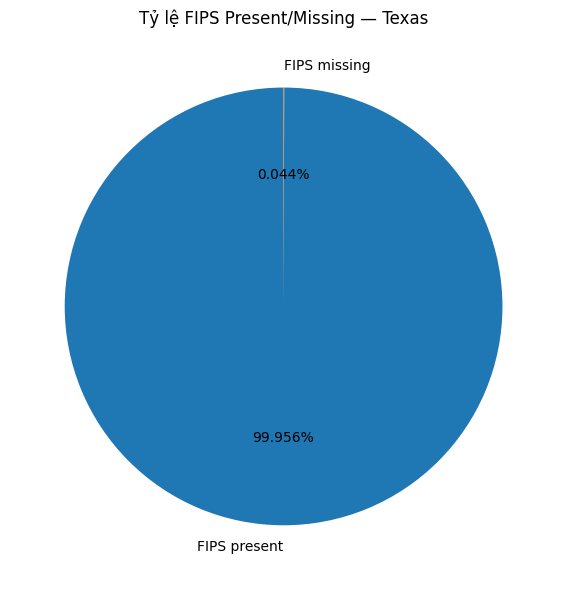

Nhận xét: Texas có 119 dòng thiếu FIPS. Trong đó 119 dòng nằm trong nhóm technical labels.
Tỷ lệ missing FIPS được giải thích bởi technical labels: 100.00%.


In [ ]:
# Pie chart — FIPS missing/present trong bang được chọn
focus_fips_missing = int(df_focus["fips"].isna().sum())
focus_fips_present = int(df_focus["fips"].notna().sum())

plt.figure(figsize=(6, 6))
plt.pie(
    [focus_fips_present, focus_fips_missing],
    labels=["FIPS present", "FIPS missing"],
    autopct="%1.3f%%",
    startangle=90
)
plt.title(f"Tỷ lệ FIPS Present/Missing — {TARGET_STATE}")
plt.tight_layout()
plt.show()

missing_in_technical = int(
    df_focus.loc[technical_county_mask, "fips"].isna().sum()
)

print(
    f"Nhận xét: {TARGET_STATE} có {focus_fips_missing:,} dòng thiếu FIPS. "
    f"Trong đó {missing_in_technical:,} dòng nằm trong nhóm technical labels."
)
if focus_fips_missing > 0:
    print(
        f"Tỷ lệ missing FIPS được giải thích bởi technical labels: "
        f"{missing_in_technical/focus_fips_missing*100:.2f}%."
    )


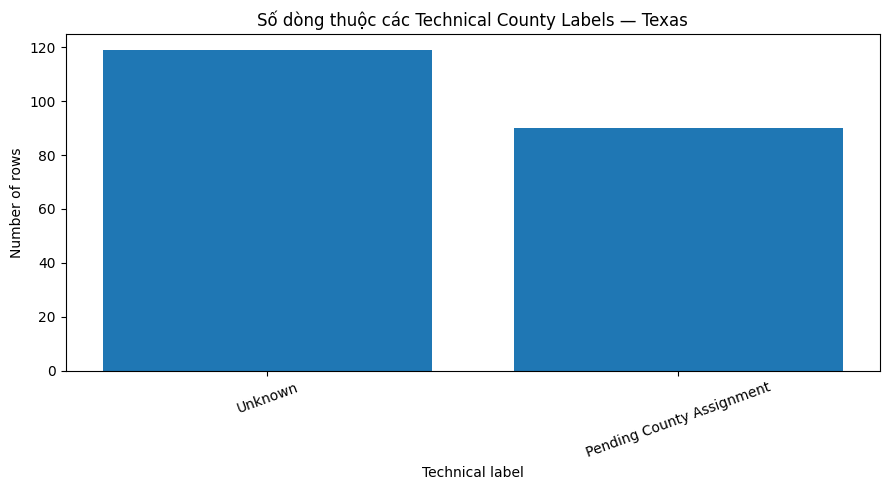

Nhận xét: các nhãn này cần được tách khỏi county thật trước khi xếp hạng hoặc tạo mô hình phân bổ nguồn lực.


In [ ]:
# Bar chart — số dòng theo technical label
if not technical_label_summary.empty:
    plt.figure(figsize=(9, 5))
    plt.bar(
        technical_label_summary["county_label"].astype(str),
        technical_label_summary["n_rows"]
    )
    plt.title(f"Số dòng thuộc các Technical County Labels — {TARGET_STATE}")
    plt.xlabel("Technical label")
    plt.ylabel("Number of rows")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    print(
        "Nhận xét: các nhãn này cần được tách khỏi county thật trước khi xếp hạng "
        "hoặc tạo mô hình phân bổ nguồn lực."
    )


## 7. Coverage theo county — dùng 2 định nghĩa

### 7.1 Internal coverage

$$ \frac{\text{số ngày có record}}{\text{số ngày từ first_date đến last_date riêng của county}} $$

Cho biết bên trong khoảng county đã xuất hiện, dữ liệu có bị đứt quãng hay không.

### 7.2 Study-window coverage

$$ \frac{\text{số ngày có record}}{\text{toàn bộ số ngày của cửa sổ nghiên cứu trong bang}} $$

Chỉ số này giúp phát hiện county xuất hiện muộn hoặc có lịch sử quan sát ngắn.

> Study-window coverage thấp **không tự động có nghĩa là dữ liệu sai**; giai đoạn đầu county có thể chưa ghi nhận ca. Đây là chỉ báo để cân nhắc khi Modeling.


In [ ]:
study_start = df_focus["date"].min()
study_end = df_focus["date"].max()
study_window_days = (study_end - study_start).days + 1

coverage = (
    df_focus[
        df_focus["date"].notna() &
        df_focus["county"].notna() &
        ~focus_unknown_mask
    ]
    .groupby("county", as_index=False)
    .agg(
        first_date=("date", "min"),
        last_date=("date", "max"),
        n_records=("date", "size"),
        n_unique_dates=("date", "nunique")
    )
)

coverage["internal_days"] = (
    coverage["last_date"] - coverage["first_date"]
).dt.days + 1

coverage["internal_coverage_pct"] = (
    coverage["n_unique_dates"] /
    coverage["internal_days"] * 100
).round(2)

coverage["study_window_days"] = study_window_days
coverage["study_window_coverage_pct"] = (
    coverage["n_unique_dates"] /
    study_window_days * 100
).round(2)

coverage = coverage.sort_values(
    ["study_window_coverage_pct", "internal_coverage_pct", "n_records"]
)

display(coverage.head(15))

print("Internal coverage trung vị:",
      f"{coverage['internal_coverage_pct'].median():.2f}%")
print("Study-window coverage trung vị:",
      f"{coverage['study_window_coverage_pct'].median():.2f}%")
print("Study-window coverage thấp nhất:",
      f"{coverage['study_window_coverage_pct'].min():.2f}%")

safe_state = re.sub(r"[^a-zA-Z0-9_-]+", "_", TARGET_STATE.strip()).strip("_").lower()
coverage.to_csv(OUTPUT_DIR / f"coverage_{safe_state}.csv", index=False)


,county,first_date,last_date,n_records,n_unique_dates,internal_days,internal_coverage_pct,study_window_days,study_window_coverage_pct
186,Pending County Assignment,2022-10-24,2023-03-23,90,90,151,59.60,1136,7.92
150,Loving,2020-11-17,2023-03-23,857,857,857,100.00,1136,75.44
134,King,2020-10-13,2023-03-23,892,892,892,100.00,1136,78.52
16,Borden,2020-09-23,2023-03-23,912,912,912,100.00,1136,80.28
216,Sterling,2020-08-13,2023-03-23,953,953,953,100.00,1136,83.89
217,Stonewall,2020-07-18,2023-03-23,979,979,979,100.00,1136,86.18
131,Kent,2020-07-14,2023-03-23,983,983,983,100.00,1136,86.53
161,McMullen,2020-07-14,2023-03-23,983,983,983,100.00,1136,86.53
77,Foard,2020-07-10,2023-03-23,987,987,987,100.00,1136,86.88
130,Kenedy,2020-07-03,2023-03-23,994,994,994,100.00,1136,87.50


Internal coverage trung vị: 100.00%
Study-window coverage trung vị: 95.69%
Study-window coverage thấp nhất: 7.92%


### Nhận xét Coverage

Kết quả hiện tại có **Internal coverage trung vị 100%** và **Study-window coverage trung vị 95,69%**, cho thấy phần lớn chuỗi county khá liên tục sau khi bắt đầu xuất hiện. Tuy nhiên mức thấp nhất **7,92%** cần được đọc cẩn thận: bảng hiện tại cho thấy `Pending County Assignment` là một nhãn kỹ thuật và chính loại label này có thể kéo minimum xuống rất thấp.

Do đó, với Modeling nên đánh giá coverage trên **county thật** thay vì dùng minimum của toàn bộ label.


### 7.1 Biểu đồ Coverage bổ sung


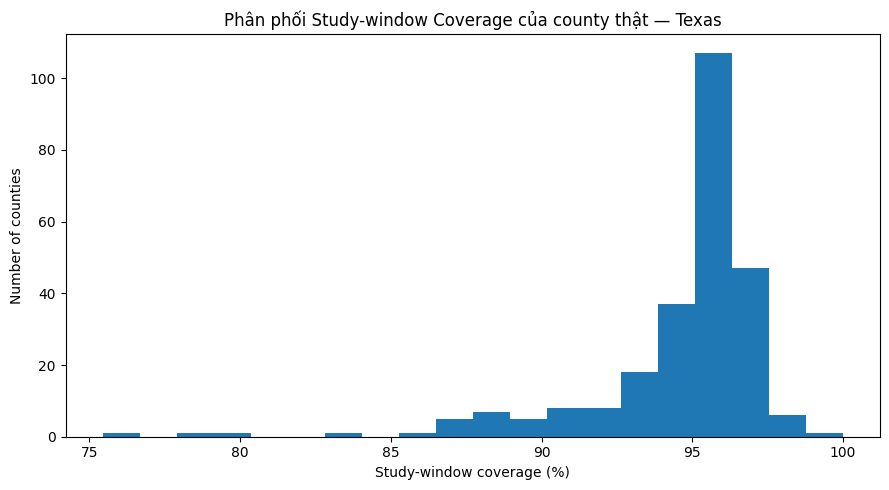

Nhận xét: sau khi loại technical labels, median study-window coverage = 95.69% và minimum = 75.44%.


In [ ]:
# Coverage distribution — county thật
coverage_real = coverage[
    ~coverage["county"].astype("string").str.strip().str.lower().isin(TECHNICAL_COUNTY_LABELS)
].copy()

plt.figure(figsize=(9, 5))
plt.hist(coverage_real["study_window_coverage_pct"].dropna(), bins=20)
plt.title(f"Phân phối Study-window Coverage của county thật — {TARGET_STATE}")
plt.xlabel("Study-window coverage (%)")
plt.ylabel("Number of counties")
plt.tight_layout()
plt.show()

print(
    f"Nhận xét: sau khi loại technical labels, median study-window coverage = "
    f"{coverage_real['study_window_coverage_pct'].median():.2f}% và minimum = "
    f"{coverage_real['study_window_coverage_pct'].min():.2f}%."
)


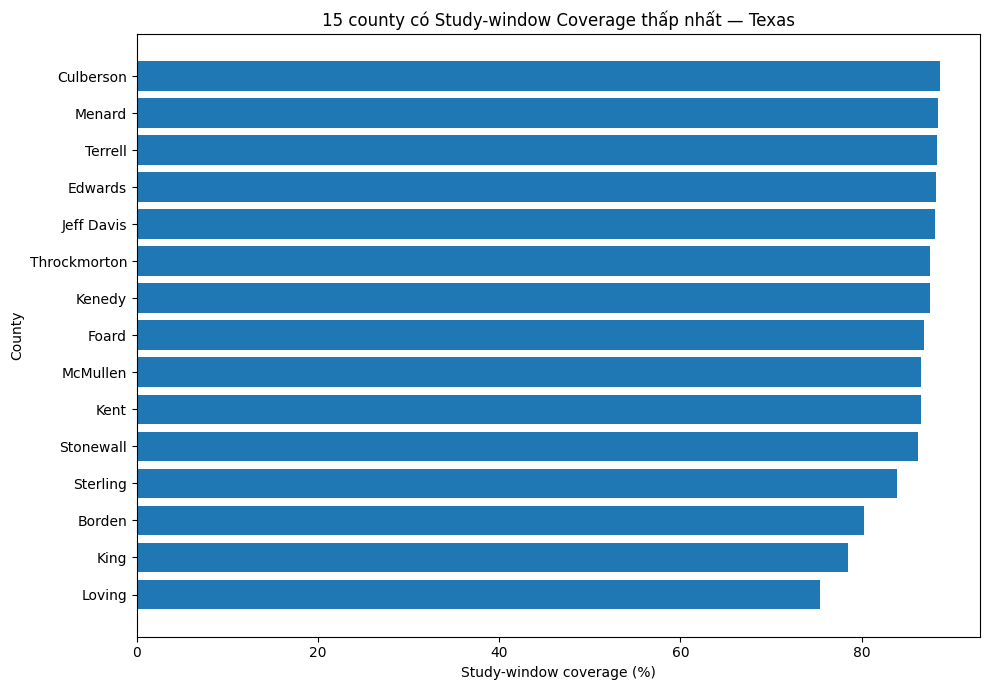

Nhận xét: county thật có coverage thấp nhất trong bảng là Loving với 75.44%. Các county coverage thấp cần được xem xét trước khi đưa vào train/test.


In [ ]:
# Bottom 15 county thật theo study-window coverage
bottom_coverage = (
    coverage_real.nsmallest(15, "study_window_coverage_pct")
    .sort_values("study_window_coverage_pct", ascending=True)
)

plt.figure(figsize=(10, 7))
plt.barh(
    bottom_coverage["county"],
    bottom_coverage["study_window_coverage_pct"]
)
plt.title(f"15 county có Study-window Coverage thấp nhất — {TARGET_STATE}")
plt.xlabel("Study-window coverage (%)")
plt.ylabel("County")
plt.tight_layout()
plt.show()

lowest = bottom_coverage.iloc[0]
print(
    f"Nhận xét: county thật có coverage thấp nhất trong bảng là {lowest['county']} "
    f"với {lowest['study_window_coverage_pct']:.2f}%. "
    "Các county coverage thấp cần được xem xét trước khi đưa vào train/test."
)


## 8. Tạo `new_cases`, `new_deaths` và rolling average thô để EDA

Vì `cases` và `deaths` là cumulative:

\[
NewCases_t = Cases_t - Cases_{t-1}
\]

Phép sai phân phải thực hiện riêng theo county sau khi sắp xếp thời gian.

### Reporting corrections

Nếu `new_cases < 0` hoặc `new_deaths < 0`, notebook **không sửa tự động**. Giá trị âm có thể là điều chỉnh lại số liệu đã công bố.

`new_cases_7d_avg_raw` trong notebook này được tính trực tiếp từ sai phân thô và chỉ dùng để **Data Understanding/EDA**. Nếu có correction âm lớn, rolling average cũng có thể âm. Không dùng biến này cho Modeling trước khi Data Preparation quyết định cách xử lý anomaly.


In [ ]:
df_focus = df_focus.sort_values(["state", "county", "date"]).copy()

grp = df_focus.groupby(["state", "county"], dropna=False, sort=False)

df_focus["new_cases"] = grp["cases"].diff()
df_focus["new_deaths"] = grp["deaths"].diff()

df_focus["new_cases_negative"] = df_focus["new_cases"] < 0
df_focus["new_deaths_negative"] = df_focus["new_deaths"] < 0

df_focus["new_cases_7d_avg_raw"] = (
    df_focus.groupby(["state", "county"], dropna=False)["new_cases"]
    .transform(lambda s: s.rolling(7, min_periods=7).mean())
)

n_neg_cases = int(df_focus["new_cases_negative"].sum())
n_neg_deaths = int(df_focus["new_deaths_negative"].sum())

print("Số quan sát new_cases âm:", f"{n_neg_cases:,}")
print("Số quan sát new_deaths âm:", f"{n_neg_deaths:,}")

negative_examples = df_focus.loc[
    df_focus["new_cases_negative"] | df_focus["new_deaths_negative"],
    ["date", "county", "cases", "deaths", "new_cases", "new_deaths"]
].head(20)

display(negative_examples)

if n_neg_cases > 0:
    print("⚠ new_cases_7d_avg_raw chỉ dùng EDA vì rolling window hiện vẫn chứa reporting corrections âm.")

# ============================================================
# REFRESH df_focus_analysis
# ============================================================
# df_focus_analysis đã được tạo ở bước audit technical labels trước khi
# new_cases/new_deaths tồn tại. Cần tạo lại sau feature creation để
# dataset phụ này có đầy đủ các cột mới dùng cho EDA bổ sung.
if "technical_county_mask" in globals():
    df_focus_analysis = df_focus.loc[~technical_county_mask].copy()
else:
    # Fallback an toàn nếu người dùng chạy cell không theo thứ tự
    technical_labels_fallback = {"unknown", "pending county assignment"}
    technical_mask_fallback = (
        df_focus["county"]
        .astype("string")
        .str.strip()
        .str.lower()
        .isin(technical_labels_fallback)
    )
    df_focus_analysis = df_focus.loc[~technical_mask_fallback].copy()

print(
    "✓ Đã refresh df_focus_analysis sau khi tạo new_cases/new_deaths. "
    f"Columns mới hiện có: "
    f"{[c for c in ['new_cases','new_deaths','new_cases_negative','new_deaths_negative','new_cases_7d_avg_raw'] if c in df_focus_analysis.columns]}"
)


Số quan sát new_cases âm: 3,678
Số quan sát new_deaths âm: 420


,date,county,cases,deaths,new_cases,new_deaths
214736,2020-06-06,Anderson,85,0.00,-2.00,0.00
258226,2020-06-20,Anderson,1006,2.00,-1.00,0.00
283323,2020-06-28,Anderson,1016,2.00,-1.00,0.00
302251,2020-07-04,Anderson,1070,2.00,-2.00,0.00
353212,2020-07-20,Anderson,2015,4.00,-2.00,0.00
385318,2020-07-30,Anderson,2174,7.00,2.00,-1.00
407838,2020-08-06,Anderson,2353,10.00,-2.00,0.00
433616,2020-08-14,Anderson,2435,15.00,-2.00,1.00
436842,2020-08-15,Anderson,2434,16.00,-1.00,1.00
449749,2020-08-19,Anderson,2423,17.00,-15.00,0.00


⚠ new_cases_7d_avg_raw chỉ dùng EDA vì rolling window hiện vẫn chứa reporting corrections âm.
✓ Đã refresh df_focus_analysis sau khi tạo new_cases/new_deaths. Columns mới hiện có: ['new_cases', 'new_deaths', 'new_cases_negative', 'new_deaths_negative', 'new_cases_7d_avg_raw']


### Nhận xét Reporting Corrections

Notebook hiện phát hiện **3.678 quan sát `new_cases < 0`** và **420 quan sát `new_deaths < 0`** tại Texas. Tương ứng xấp xỉ **1,35%** và **0,15%** tổng số county-day. Đây không phải tỷ lệ quá lớn nhưng đủ để tạo các spike âm mạnh; vì vậy không được `abs()` hoặc đổi thành 0 mà không có quy tắc rõ ràng.

Ví dụ Anderson có những lần điều chỉnh khá lớn, cho thấy raw daily differences có thể chứa **data revision**, không chỉ phản ánh diễn biến dịch thực tế.


### 8.1 Trực quan hóa Reporting Corrections


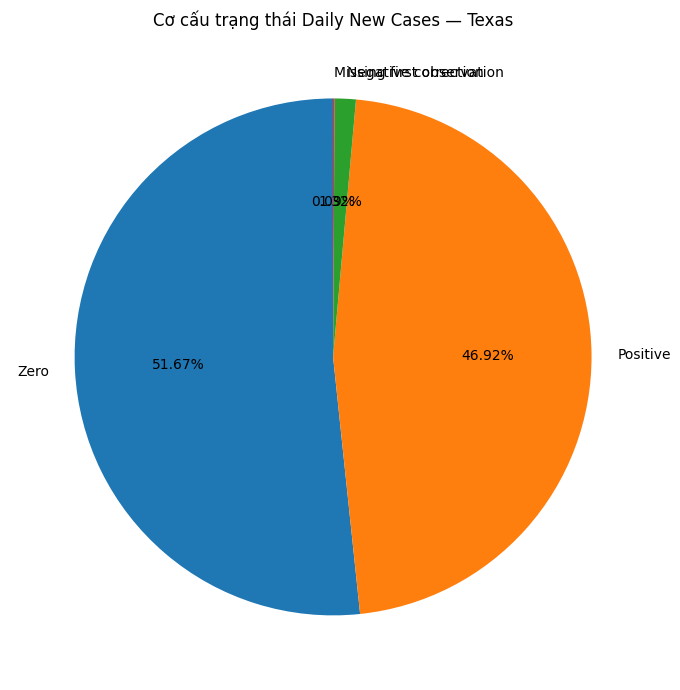

Nhận xét cơ cấu:
- Zero: 141,182 (51.67%).
- Positive: 128,201 (46.92%).
- Negative correction: 3,612 (1.32%).
- Missing first observation: 254 (0.09%).


In [ ]:
# Guard: bảo đảm df_focus_analysis có các cột được tạo ở bước trước
required_cols = {
    "new_cases",
    "new_deaths",
    "new_cases_negative",
    "new_deaths_negative",
    "new_cases_7d_avg_raw"
}

if (
    "df_focus_analysis" not in globals()
    or not required_cols.issubset(df_focus_analysis.columns)
):
    if "technical_county_mask" in globals():
        df_focus_analysis = df_focus.loc[~technical_county_mask].copy()
    else:
        technical_labels_fallback = {"unknown", "pending county assignment"}
        technical_mask_fallback = (
            df_focus["county"]
            .astype("string")
            .str.strip()
            .str.lower()
            .isin(technical_labels_fallback)
        )
        df_focus_analysis = df_focus.loc[~technical_mask_fallback].copy()

# Pie chart — Positive / Zero / Negative daily new cases
case_status = pd.Series(
    np.where(
        df_focus_analysis["new_cases"].isna(), "Missing first observation",
        np.where(
            df_focus_analysis["new_cases"] < 0, "Negative correction",
            np.where(df_focus_analysis["new_cases"] == 0, "Zero", "Positive")
        )
    )
).value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    case_status.values,
    labels=case_status.index,
    autopct="%1.2f%%",
    startangle=90
)
plt.title(f"Cơ cấu trạng thái Daily New Cases — {TARGET_STATE}")
plt.tight_layout()
plt.show()

print("Nhận xét cơ cấu:")
for label, count in case_status.items():
    print(f"- {label}: {count:,} ({count/case_status.sum()*100:.2f}%).")


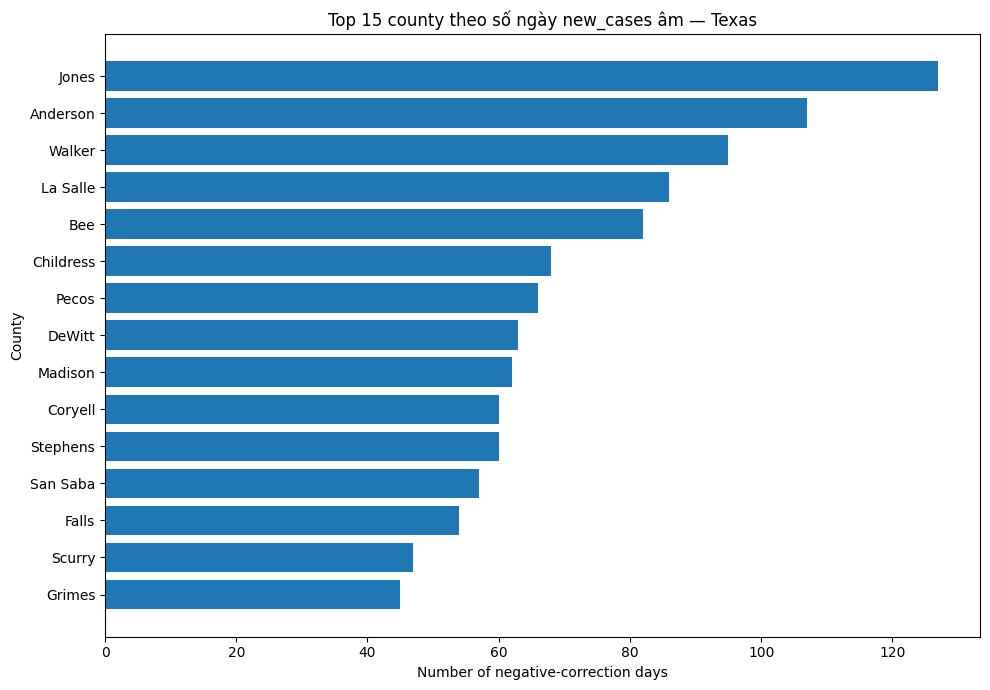

Nhận xét: Jones có số ngày new_cases âm nhiều nhất trong nhóm top 15 với 127 ngày.


In [ ]:
# Top county theo số lần reporting correction âm
correction_by_county = (
    df_focus_analysis.groupby("county", as_index=False)
    .agg(
        negative_case_days=("new_cases_negative", "sum"),
        negative_death_days=("new_deaths_negative", "sum")
    )
)

top_corrections = (
    correction_by_county
    .nlargest(15, "negative_case_days")
    .sort_values("negative_case_days")
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_corrections["county"],
    top_corrections["negative_case_days"]
)
plt.title(f"Top 15 county theo số ngày new_cases âm — {TARGET_STATE}")
plt.xlabel("Number of negative-correction days")
plt.ylabel("County")
plt.tight_layout()
plt.show()

r = top_corrections.iloc[-1]
print(
    f"Nhận xét: {r['county']} có số ngày new_cases âm nhiều nhất trong nhóm top 15 "
    f"với {int(r['negative_case_days'])} ngày."
)


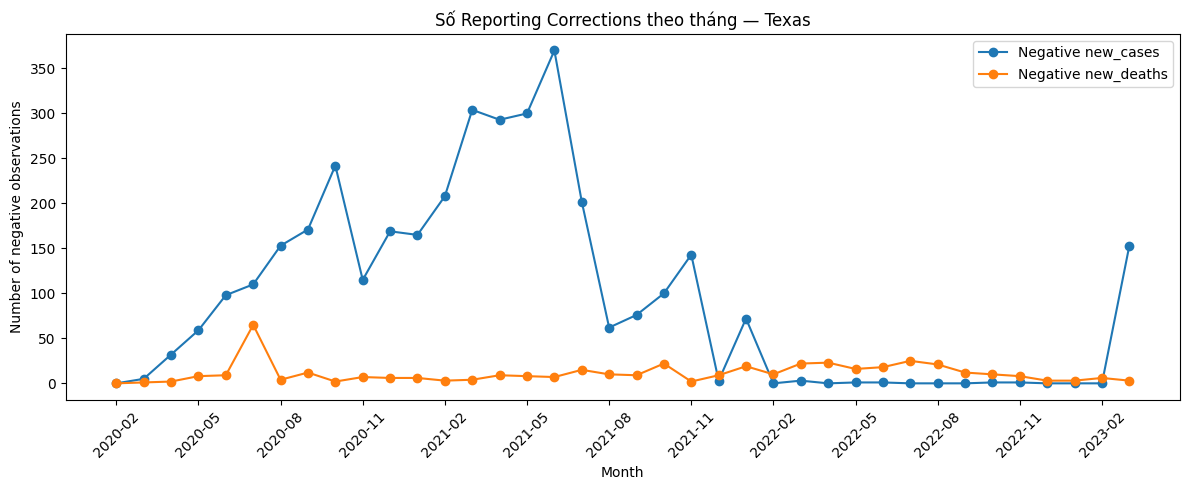

Nhận xét: tháng có nhiều new_cases âm nhất là 2021-06 với 370 quan sát.


In [ ]:
# Reporting corrections theo tháng
correction_monthly = df_focus_analysis.copy()
correction_monthly["month"] = correction_monthly["date"].dt.to_period("M").astype(str)

correction_monthly = (
    correction_monthly.groupby("month", as_index=False)
    .agg(
        negative_case_days=("new_cases_negative", "sum"),
        negative_death_days=("new_deaths_negative", "sum")
    )
)

plt.figure(figsize=(12, 5))
plt.plot(
    correction_monthly["month"],
    correction_monthly["negative_case_days"],
    marker="o",
    label="Negative new_cases"
)
plt.plot(
    correction_monthly["month"],
    correction_monthly["negative_death_days"],
    marker="o",
    label="Negative new_deaths"
)
plt.title(f"Số Reporting Corrections theo tháng — {TARGET_STATE}")
plt.xlabel("Month")
plt.ylabel("Number of negative observations")
plt.xticks(
    range(0, len(correction_monthly), max(1, len(correction_monthly)//12)),
    correction_monthly["month"].iloc[
        ::max(1, len(correction_monthly)//12)
    ],
    rotation=45
)
plt.legend()
plt.tight_layout()
plt.show()

peak_corr = correction_monthly.loc[
    correction_monthly["negative_case_days"].idxmax()
]
print(
    f"Nhận xét: tháng có nhiều new_cases âm nhất là {peak_corr['month']} "
    f"với {int(peak_corr['negative_case_days'])} quan sát."
)


## 9. Thống kê mô tả

Theo bài giảng:

- **Central tendency:** mean, median;
- **Variability:** standard deviation, quartiles, IQR, min/max;
- **Distribution:** histogram và boxplot.

Với COVID, chênh lệch lớn giữa mean và median thường cho thấy phân phối lệch mạnh giữa các county/ngày.


In [ ]:
numeric_cols = [
    c for c in
    ["cases", "deaths", "new_cases", "new_deaths", "new_cases_7d_avg_raw"]
    if c in df_focus.columns
]

desc = df_focus[numeric_cols].describe(
    percentiles=[0.25, 0.5, 0.75]
).T

desc["median"] = df_focus[numeric_cols].median()
desc["IQR"] = desc["75%"] - desc["25%"]
desc["skewness"] = df_focus[numeric_cols].skew(numeric_only=True)

display(desc)

if "new_cases" in desc.index:
    mean_nc = desc.loc["new_cases", "mean"]
    med_nc = desc.loc["new_cases", "median"]
    print(
        f"Nhận xét: mean new_cases = {mean_nc:,.2f}, "
        f"median = {med_nc:,.2f}. "
        "Khoảng cách giữa mean và median là dấu hiệu phân phối không đối xứng."
    )

desc.to_csv(OUTPUT_DIR / f"descriptive_stats_{safe_state}.csv")


,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
cases,"273,458.00","16,971.48","72,555.52",0.00,473.00,"1,983.00","6,985.75","1,312,744.00","1,983.00","6,512.75",9.78
deaths,"273,458.00",229.91,796.50,0.00,11.00,45.00,136.00,"11,642.00",45.00,125.00,8.27
new_cases,"273,202.00",30.92,304.86,"-18,817.00",0.00,0.00,6.00,"75,982.00",0.00,6.00,87.75
new_deaths,"273,202.00",0.35,2.17,-86.00,0.00,0.00,0.00,455.00,0.00,0.00,46.26
new_cases_7d_avg_raw,"271,666.00",31.05,203.82,"-2,041.57",0.43,2.29,10.14,"19,442.29",2.29,9.71,34.57


Nhận xét: mean new_cases = 30.92, median = 0.00. Khoảng cách giữa mean và median là dấu hiệu phân phối không đối xứng.


### Nhận xét thống kê mô tả

Kết quả hiện tại cho thấy `new_cases` có **mean khoảng 30,92 nhưng median bằng 0**. Đây là chênh lệch rất lớn và là bằng chứng rõ ràng rằng phân phối bị **lệch phải mạnh**: phần lớn county-day có số ca mới rất thấp/0, trong khi một số county/ngày có giá trị rất lớn kéo mean tăng lên.

Vì vậy khi mô tả dữ liệu nên báo cáo **median + IQR** song song với **mean + standard deviation**, không chỉ dùng trung bình.


### 9.1 Correlation Heatmap của các biến số

Heatmap này chỉ mô tả **mức liên hệ tuyến tính**, không chứng minh quan hệ nhân quả.


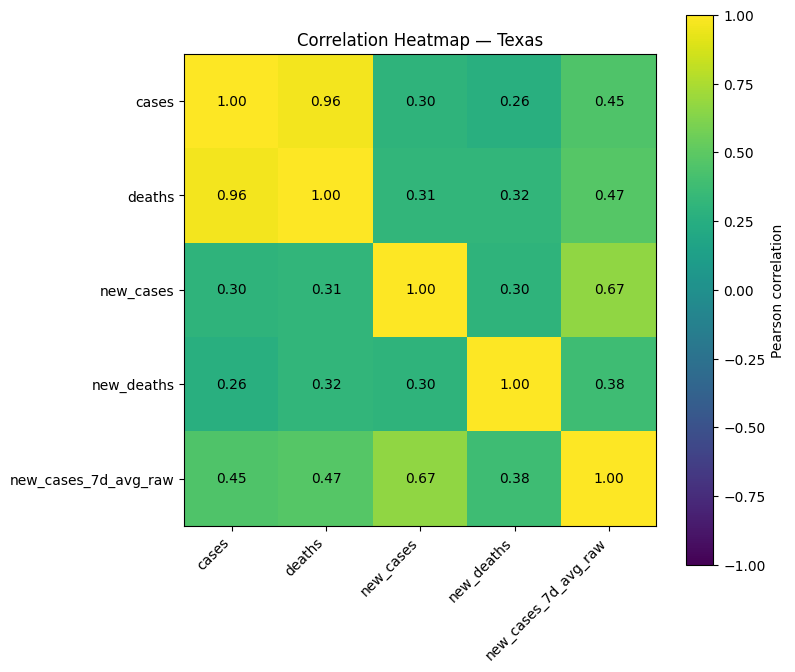

Nhận xét: cặp có |correlation| lớn nhất ngoài đường chéo là cases ↔ deaths với r = 0.964. Không diễn giải kết quả này thành quan hệ nhân quả.


In [ ]:
corr_cols = [
    c for c in [
        "cases", "deaths", "new_cases", "new_deaths", "new_cases_7d_avg_raw"
    ]
    if c in df_focus_analysis.columns
]

corr_matrix = df_focus_analysis[corr_cols].corr()

plt.figure(figsize=(8, 7))
im = plt.imshow(corr_matrix.values, vmin=-1, vmax=1)
plt.colorbar(im, label="Pearson correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center", va="center"
        )

plt.title(f"Correlation Heatmap — {TARGET_STATE}")
plt.tight_layout()
plt.show()

pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        pairs.append(
            (corr_cols[i], corr_cols[j], corr_matrix.iloc[i, j])
        )

if pairs:
    strongest = max(pairs, key=lambda x: abs(x[2]))
    print(
        f"Nhận xét: cặp có |correlation| lớn nhất ngoài đường chéo là "
        f"{strongest[0]} ↔ {strongest[1]} với r = {strongest[2]:.3f}. "
        "Không diễn giải kết quả này thành quan hệ nhân quả."
    )


### 9.2 Boxplot cải tiến dùng Rolling Average 7 ngày

Boxplot `new_cases` theo năm có median bằng 0 nên khó phân biệt. Vì vậy biểu đồ bổ sung sử dụng `new_cases_7d_avg_raw`, vẫn giữ nguyên cảnh báo rằng đây là rolling average **chưa xử lý reporting corrections**.

Năm 2023 chỉ có dữ liệu đến tháng 3, vì vậy **không so sánh tổng lượng của 2023 với các năm đầy đủ như thể cùng độ dài quan sát**.


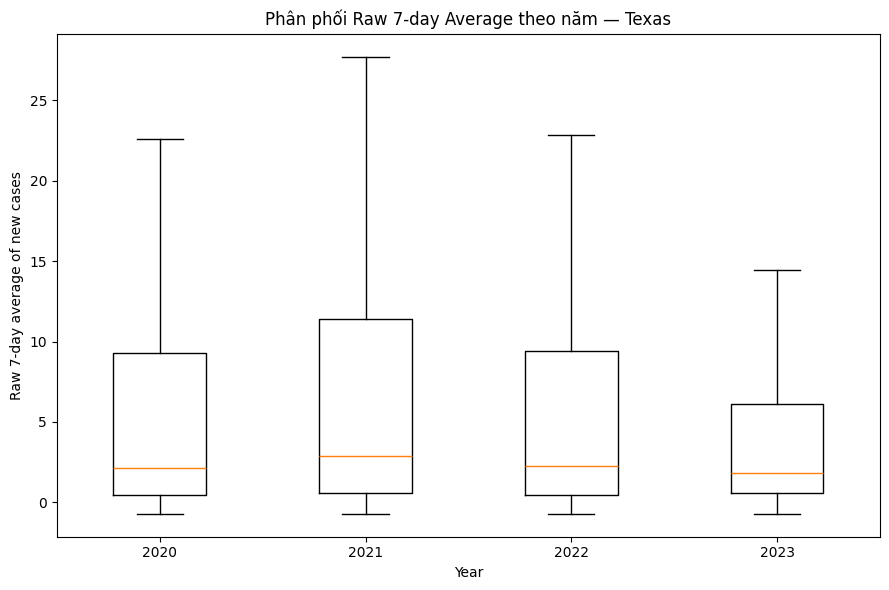

,median,q1,q3,mean,IQR
year,,,,,
2020,2.14,0.43,9.71,26.25,9.29
2021,2.71,0.57,11.71,30.38,11.14
2022,2.29,0.43,10.00,38.46,9.57
2023,1.57,0.43,5.71,16.23,5.29


Nhận xét: rolling average giảm nhiễu ngày và tạo khác biệt giữa các năm rõ hơn so với boxplot trực tiếp trên new_cases. 2023 là năm chưa đầy đủ.


In [ ]:
roll_box = df_focus_analysis.dropna(
    subset=["date", "new_cases_7d_avg_raw"]
).copy()
roll_box["year"] = roll_box["date"].dt.year

# Chỉ cắt vùng hiển thị để boxplot đọc được; không xóa dữ liệu gốc.
lo, hi = roll_box["new_cases_7d_avg_raw"].quantile([0.01, 0.99])
roll_box_view = roll_box[
    roll_box["new_cases_7d_avg_raw"].between(lo, hi)
]

years = sorted(roll_box_view["year"].unique())
box_data = [
    roll_box_view.loc[
        roll_box_view["year"] == y,
        "new_cases_7d_avg_raw"
    ].values
    for y in years
]

plt.figure(figsize=(9, 6))
plt.boxplot(box_data, tick_labels=years, showfliers=False)
plt.title(f"Phân phối Raw 7-day Average theo năm — {TARGET_STATE}")
plt.xlabel("Year")
plt.ylabel("Raw 7-day average of new cases")
plt.tight_layout()
plt.show()

rolling_year_stats = (
    roll_box.groupby("year")["new_cases_7d_avg_raw"]
    .agg(
        median="median",
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
        mean="mean"
    )
)
rolling_year_stats["IQR"] = (
    rolling_year_stats["q3"] - rolling_year_stats["q1"]
)

display(rolling_year_stats)
print(
    "Nhận xét: rolling average giảm nhiễu ngày và tạo khác biệt giữa các năm rõ hơn "
    "so với boxplot trực tiếp trên new_cases. 2023 là năm chưa đầy đủ."
)


## 9.3 Phân tích và so sánh dữ liệu giữa các năm

Mục tiêu của phần này là trả lời bằng **số liệu**:

1. Các năm có mức độ và độ biến động COVID khác nhau hay không?
2. Năm nào có mean/median/IQR/P95 cao hơn?
3. 2020 và 2023 có phải là năm đầy đủ để so sánh trực tiếp hay không?
4. Có bằng chứng thống kê cho thấy các năm đầy đủ khác nhau không?
5. Kết quả này gợi ý gì cho việc chọn **1 năm** hay **nhiều năm** ở bước Modeling?

### Nguyên tắc

- Không so sánh tổng số của một năm chưa đầy đủ với một năm đầy đủ như thể chúng có cùng thời lượng.
- Ưu tiên `new_cases_7d_avg_raw` hơn `new_cases` để giảm nhiễu ngày, nhưng vẫn giữ cảnh báo rằng rolling average này chưa xử lý reporting corrections.
- Khi kiểm định giữa các năm, dùng **county-level aggregated statistics** để giảm hiện tượng một county có hàng trăm quan sát ngày làm p-value trở nên quá nhạy.


### 9.3.1 Kiểm tra năm đầy đủ / chưa đầy đủ

Một năm được đánh dấu **FULL** nếu dữ liệu của phạm vi phân tích có quan sát từ 01/01 đến 31/12 của năm đó. Nếu không, năm được đánh dấu **PARTIAL**.

Điều này rất quan trọng vì dữ liệu hiện tại bắt đầu trong năm 2020 và kết thúc vào tháng 3/2023.


In [ ]:
# ============================================================
# 9.3.1 YEAR COVERAGE / COMPLETENESS
# ============================================================
year_scope = (
    df_focus_analysis.dropna(subset=["date"])
    .assign(year=lambda x: x["date"].dt.year)
    .groupby("year", as_index=False)
    .agg(
        first_date=("date", "min"),
        last_date=("date", "max"),
        unique_observed_days=("date", "nunique"),
        n_rows=("date", "size"),
        n_counties=("county", "nunique")
    )
)

def days_in_year(year):
    start = pd.Timestamp(year=year, month=1, day=1)
    end = pd.Timestamp(year=year, month=12, day=31)
    return (end - start).days + 1

year_scope["calendar_days"] = year_scope["year"].apply(days_in_year)
year_scope["calendar_coverage_pct"] = (
    year_scope["unique_observed_days"] / year_scope["calendar_days"] * 100
).round(2)

year_scope["is_full_calendar_year"] = (
    (year_scope["first_date"].dt.month.eq(1)) &
    (year_scope["first_date"].dt.day.eq(1)) &
    (year_scope["last_date"].dt.month.eq(12)) &
    (year_scope["last_date"].dt.day.eq(31))
)

year_scope["status"] = np.where(
    year_scope["is_full_calendar_year"],
    "FULL",
    "PARTIAL"
)

display(year_scope)

print("Nhận xét tự động:")
for _, r in year_scope.iterrows():
    print(
        f"- {int(r['year'])}: {r['status']} | "
        f"{r['first_date'].date()} → {r['last_date'].date()} | "
        f"{int(r['unique_observed_days'])}/{int(r['calendar_days'])} ngày "
        f"({r['calendar_coverage_pct']:.2f}%)."
    )

full_years = year_scope.loc[
    year_scope["is_full_calendar_year"], "year"
].astype(int).tolist()

partial_years = year_scope.loc[
    ~year_scope["is_full_calendar_year"], "year"
].astype(int).tolist()

print("\nNăm đầy đủ:", full_years)
print("Năm chưa đầy đủ:", partial_years)

year_scope.to_csv(
    OUTPUT_DIR / f"year_scope_{safe_state}.csv",
    index=False
)


,year,first_date,last_date,unique_observed_days,n_rows,n_counties,calendar_days,calendar_coverage_pct,is_full_calendar_year,status
0,2020,2020-02-12,2020-12-31,324,67001,254,366,88.52,False,PARTIAL
1,2021,2021-01-01,2021-12-31,365,92710,254,365,100.00,True,FULL
2,2022,2022-01-01,2022-12-31,365,92710,254,365,100.00,True,FULL
3,2023,2023-01-01,2023-03-23,82,20828,254,365,22.47,False,PARTIAL


Nhận xét tự động:
- 2020: PARTIAL | 2020-02-12 → 2020-12-31 | 324/366 ngày (88.52%).
- 2021: FULL | 2021-01-01 → 2021-12-31 | 365/365 ngày (100.00%).
- 2022: FULL | 2022-01-01 → 2022-12-31 | 365/365 ngày (100.00%).
- 2023: PARTIAL | 2023-01-01 → 2023-03-23 | 82/365 ngày (22.47%).

Năm đầy đủ: [2021, 2022]
Năm chưa đầy đủ: [2020, 2023]


### 9.3.2 Thống kê mô tả theo năm

Các chỉ số sử dụng:

- **Mean:** nhạy với các đợt bùng phát rất lớn.
- **Median:** mô tả mức điển hình tốt hơn khi phân phối lệch.
- **IQR:** đo độ biến thiên của 50% quan sát trung tâm.
- **P95:** cho biết mức rất cao nhưng ít bị chi phối bởi một điểm cực trị duy nhất như `max`.
- **Total new cases:** chỉ dùng để mô tả quy mô trong năm; không dùng để so trực tiếp FULL với PARTIAL year.


In [ ]:
# ============================================================
# 9.3.2 ANNUAL DESCRIPTIVE STATISTICS
# ============================================================
annual_df = df_focus_analysis.dropna(
    subset=["date", "new_cases_7d_avg_raw"]
).copy()
annual_df["year"] = annual_df["date"].dt.year

annual_stats = (
    annual_df.groupby("year")["new_cases_7d_avg_raw"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
        p95=lambda s: s.quantile(0.95),
        max="max"
    )
    .reset_index()
)

annual_stats["IQR"] = annual_stats["q3"] - annual_stats["q1"]

annual_totals = (
    df_focus_analysis.dropna(subset=["date"])
    .assign(year=lambda x: x["date"].dt.year)
    .groupby("year", as_index=False)
    .agg(
        total_new_cases=("new_cases", "sum"),
        total_new_deaths=("new_deaths", "sum")
    )
)

annual_stats = (
    annual_stats
    .merge(annual_totals, on="year", how="left")
    .merge(
        year_scope[[
            "year", "status",
            "unique_observed_days",
            "calendar_coverage_pct"
        ]],
        on="year",
        how="left"
    )
)

display(annual_stats.round(2))

# So sánh % giữa các năm đầy đủ nếu có >= 2 năm
full_stats = annual_stats[
    annual_stats["year"].isin(full_years)
].sort_values("year")

if len(full_stats) >= 2:
    print("\nSo sánh các năm FULL:")
    for i in range(1, len(full_stats)):
        prev = full_stats.iloc[i - 1]
        curr = full_stats.iloc[i]

        mean_change = (
            (curr["mean"] - prev["mean"]) / prev["mean"] * 100
            if prev["mean"] != 0 else np.nan
        )
        median_change = (
            (curr["median"] - prev["median"]) / prev["median"] * 100
            if prev["median"] != 0 else np.nan
        )

        print(
            f"- {int(prev['year'])} → {int(curr['year'])}: "
            f"mean thay đổi {mean_change:.2f}%, "
            f"median thay đổi {median_change:.2f}%, "
            f"IQR {prev['IQR']:.2f} → {curr['IQR']:.2f}."
        )

annual_stats.to_csv(
    OUTPUT_DIR / f"annual_statistics_{safe_state}.csv",
    index=False
)


,year,n,mean,median,std,q1,q3,p95,max,IQR,total_new_cases,total_new_deaths,status,unique_observed_days,calendar_coverage_pct
0,2020,65223,26.25,2.14,116.83,0.43,9.71,102.29,"2,911.14",9.29,"1,770,194.00","28,154.00",PARTIAL,324,88.52
1,2021,92710,30.38,2.71,144.38,0.57,11.71,118.57,"4,455.86",11.14,"2,804,354.00","47,907.00",FULL,365,100.00
2,2022,92710,38.46,2.29,289.52,0.43,10.00,132.79,"19,442.29",9.57,"3,534,975.00","16,647.00",FULL,365,100.00
3,2023,20828,16.23,1.57,177.86,0.43,5.71,66.71,"6,205.71",5.29,"326,546.00","1,809.00",PARTIAL,82,22.47



So sánh các năm FULL:
- 2021 → 2022: mean thay đổi 26.60%, median thay đổi -15.79%, IQR 11.14 → 9.57.


### 9.3.3 Biểu đồ Mean vs Median theo năm

Nếu mean cao hơn median rất nhiều, phân phối có xu hướng bị kéo lên bởi các đợt bùng phát lớn hoặc một số county có số ca rất cao.

Với năm PARTIAL, biểu đồ vẫn hữu ích để mô tả nhưng không được dùng để kết luận “cả năm thấp hơn/cao hơn”.


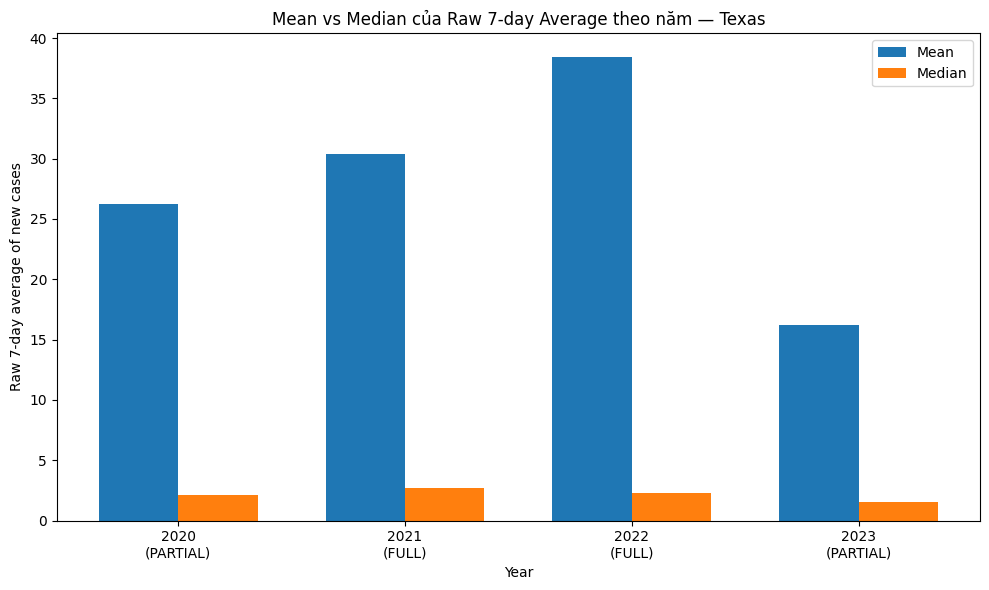

- 2020 (PARTIAL): mean=26.25, median=2.14, IQR=9.29, P95=102.29.
- 2021 (FULL): mean=30.38, median=2.71, IQR=11.14, P95=118.57.
- 2022 (FULL): mean=38.46, median=2.29, IQR=9.57, P95=132.79.
- 2023 (PARTIAL): mean=16.23, median=1.57, IQR=5.29, P95=66.71.


In [ ]:
# Grouped bar chart: annual mean vs median
plot_stats = annual_stats.sort_values("year").copy()

x = np.arange(len(plot_stats))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(
    x - width/2,
    plot_stats["mean"],
    width,
    label="Mean"
)
plt.bar(
    x + width/2,
    plot_stats["median"],
    width,
    label="Median"
)

labels = [
    f"{int(y)}\n({status})"
    for y, status in zip(
        plot_stats["year"],
        plot_stats["status"]
    )
]

plt.xticks(x, labels)
plt.title(f"Mean vs Median của Raw 7-day Average theo năm — {TARGET_STATE}")
plt.xlabel("Year")
plt.ylabel("Raw 7-day average of new cases")
plt.legend()
plt.tight_layout()
plt.show()

for _, r in plot_stats.iterrows():
    print(
        f"- {int(r['year'])} ({r['status']}): "
        f"mean={r['mean']:.2f}, median={r['median']:.2f}, "
        f"IQR={r['IQR']:.2f}, P95={r['p95']:.2f}."
    )


### 9.3.4 Boxplot và Violin Plot theo năm

- **Boxplot:** nhấn mạnh median và IQR.
- **Violin plot:** cho thấy hình dạng phân phối rõ hơn.

Hai biểu đồ dùng cùng biến `new_cases_7d_avg_raw` và cùng vùng hiển thị 1%–99% để tránh một vài cực trị làm biểu đồ không đọc được. Việc giới hạn **chỉ áp dụng cho hiển thị**, không xóa dữ liệu gốc.


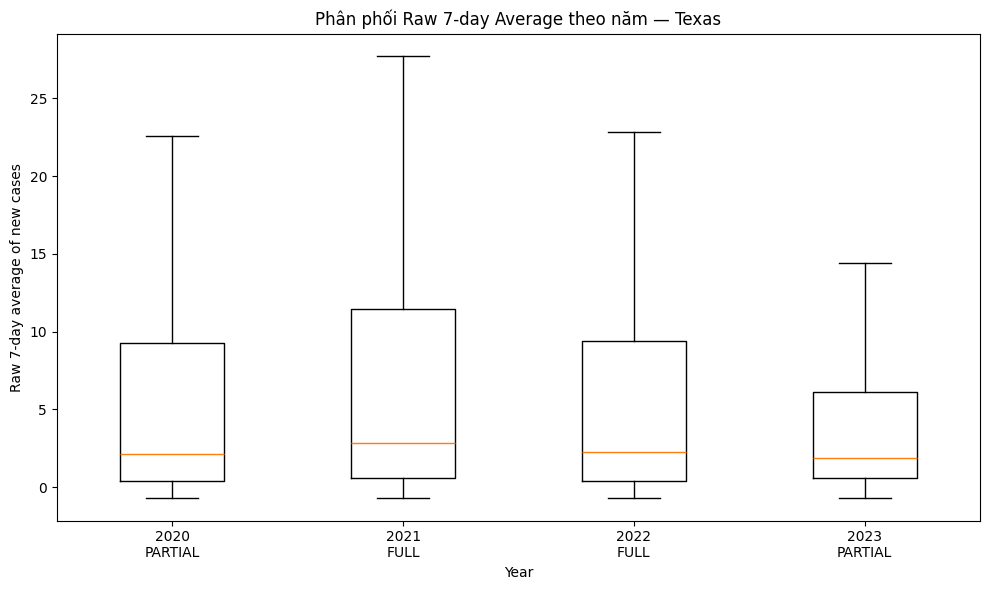

Vùng hiển thị 1%-99%: -0.71 → 520.14. Dữ liệu ngoài khoảng này vẫn được giữ nguyên trong dataframe.


In [ ]:
# Boxplot annual distribution — trimmed display only
annual_plot = annual_df.copy()

lo, hi = annual_plot["new_cases_7d_avg_raw"].quantile([0.01, 0.99])
annual_plot_view = annual_plot[
    annual_plot["new_cases_7d_avg_raw"].between(lo, hi)
]

years_plot = sorted(annual_plot_view["year"].unique())
box_data = [
    annual_plot_view.loc[
        annual_plot_view["year"] == y,
        "new_cases_7d_avg_raw"
    ].values
    for y in years_plot
]

plt.figure(figsize=(10, 6))
plt.boxplot(
    box_data,
    tick_labels=[
        f"{y}\n{'FULL' if y in full_years else 'PARTIAL'}"
        for y in years_plot
    ],
    showfliers=False
)
plt.title(f"Phân phối Raw 7-day Average theo năm — {TARGET_STATE}")
plt.xlabel("Year")
plt.ylabel("Raw 7-day average of new cases")
plt.tight_layout()
plt.show()

print(
    f"Vùng hiển thị 1%-99%: {lo:.2f} → {hi:.2f}. "
    "Dữ liệu ngoài khoảng này vẫn được giữ nguyên trong dataframe."
)


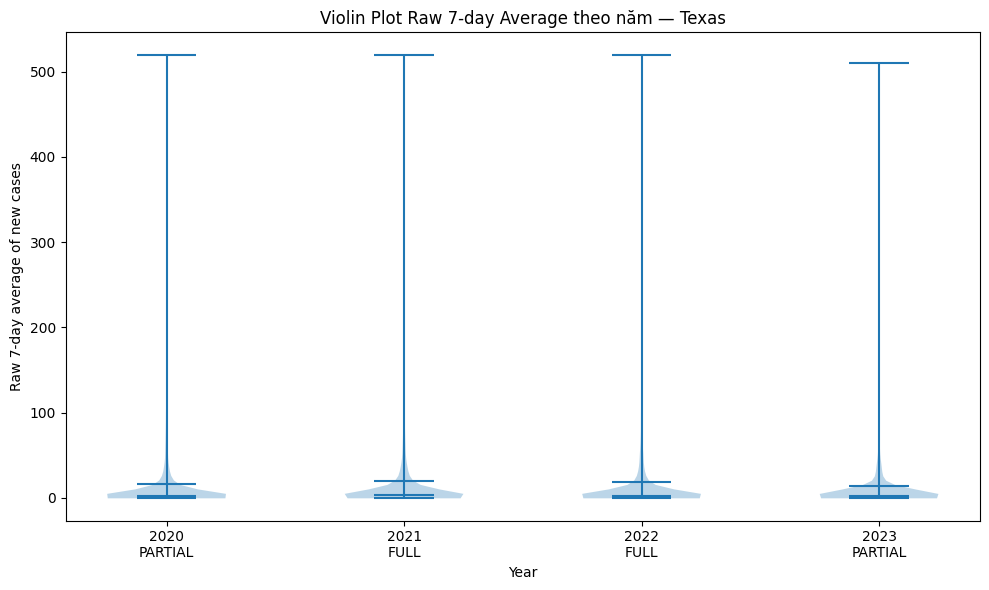

Nhận xét: violin rộng ở vùng nào thì nhiều quan sát tập trung ở vùng đó. Mean và median được hiển thị để hỗ trợ đọc phân phối lệch.


In [ ]:
# Violin plot annual distribution
violin_data = [
    annual_plot_view.loc[
        annual_plot_view["year"] == y,
        "new_cases_7d_avg_raw"
    ].dropna().values
    for y in years_plot
]

plt.figure(figsize=(10, 6))
plt.violinplot(
    violin_data,
    positions=np.arange(1, len(years_plot) + 1),
    showmeans=True,
    showmedians=True
)
plt.xticks(
    np.arange(1, len(years_plot) + 1),
    [
        f"{y}\n{'FULL' if y in full_years else 'PARTIAL'}"
        for y in years_plot
    ]
)
plt.title(f"Violin Plot Raw 7-day Average theo năm — {TARGET_STATE}")
plt.xlabel("Year")
plt.ylabel("Raw 7-day average of new cases")
plt.tight_layout()
plt.show()

print(
    "Nhận xét: violin rộng ở vùng nào thì nhiều quan sát tập trung ở vùng đó. "
    "Mean và median được hiển thị để hỗ trợ đọc phân phối lệch."
)


### 9.3.5 So sánh cùng tháng giữa các năm

Để tránh sai lầm do năm 2020/2023 không đầy đủ, biểu đồ này so sánh **monthly mean của rolling average** theo `month_of_year` (1–12).

Cách nhìn này giúp trả lời: cùng một tháng trong năm, cường độ được ghi nhận có khác nhau giữa các năm không?


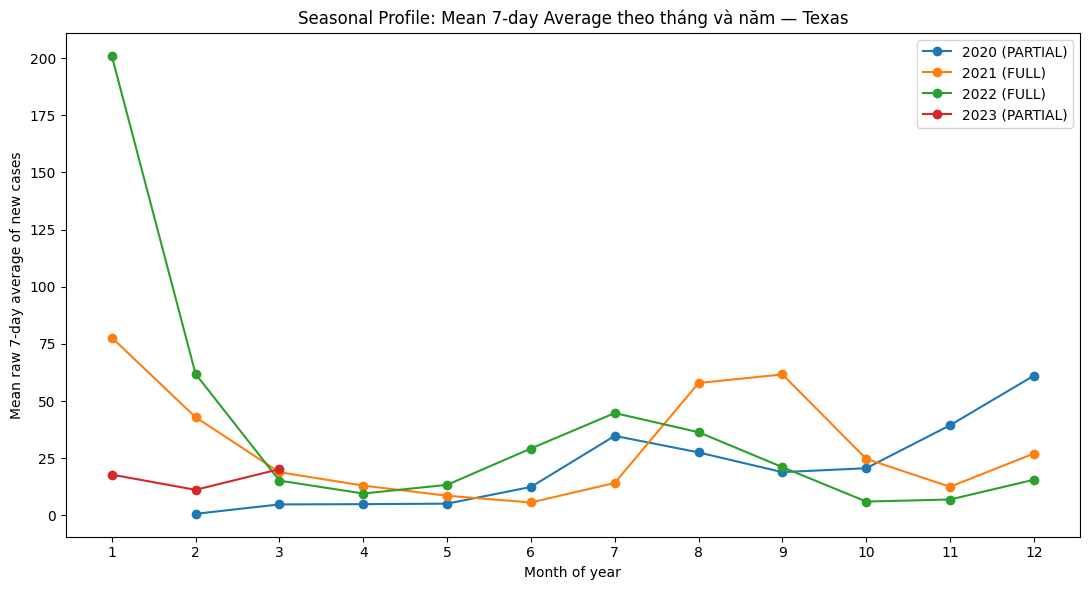

Peak month theo mean 7-day average:
- 2020 (PARTIAL): tháng 12, mean=61.11.
- 2021 (FULL): tháng 1, mean=77.76.
- 2022 (FULL): tháng 1, mean=201.01.
- 2023 (PARTIAL): tháng 3, mean=20.22.


In [ ]:
# Monthly seasonal profile by year
seasonal = annual_df.copy()
seasonal["month_of_year"] = seasonal["date"].dt.month

seasonal_summary = (
    seasonal.groupby(["year", "month_of_year"], as_index=False)
    .agg(
        mean_7d_avg=("new_cases_7d_avg_raw", "mean"),
        median_7d_avg=("new_cases_7d_avg_raw", "median"),
        n=("new_cases_7d_avg_raw", "count")
    )
)

plt.figure(figsize=(11, 6))

for year, g in seasonal_summary.groupby("year"):
    plt.plot(
        g["month_of_year"],
        g["mean_7d_avg"],
        marker="o",
        label=f"{int(year)} ({'FULL' if year in full_years else 'PARTIAL'})"
    )

plt.xticks(range(1, 13))
plt.title(f"Seasonal Profile: Mean 7-day Average theo tháng và năm — {TARGET_STATE}")
plt.xlabel("Month of year")
plt.ylabel("Mean raw 7-day average of new cases")
plt.legend()
plt.tight_layout()
plt.show()

# Peak month for each year
print("Peak month theo mean 7-day average:")
for year, g in seasonal_summary.groupby("year"):
    peak = g.loc[g["mean_7d_avg"].idxmax()]
    print(
        f"- {int(year)} ({'FULL' if year in full_years else 'PARTIAL'}): "
        f"tháng {int(peak['month_of_year'])}, "
        f"mean={peak['mean_7d_avg']:.2f}."
    )


### 9.3.6 Heatmap Year × Month

Heatmap giúp nhìn nhanh các wave theo thời gian. Ô trống ở năm PARTIAL không được hiểu là `0`; đó là **không có tháng quan sát trong phạm vi dữ liệu**.


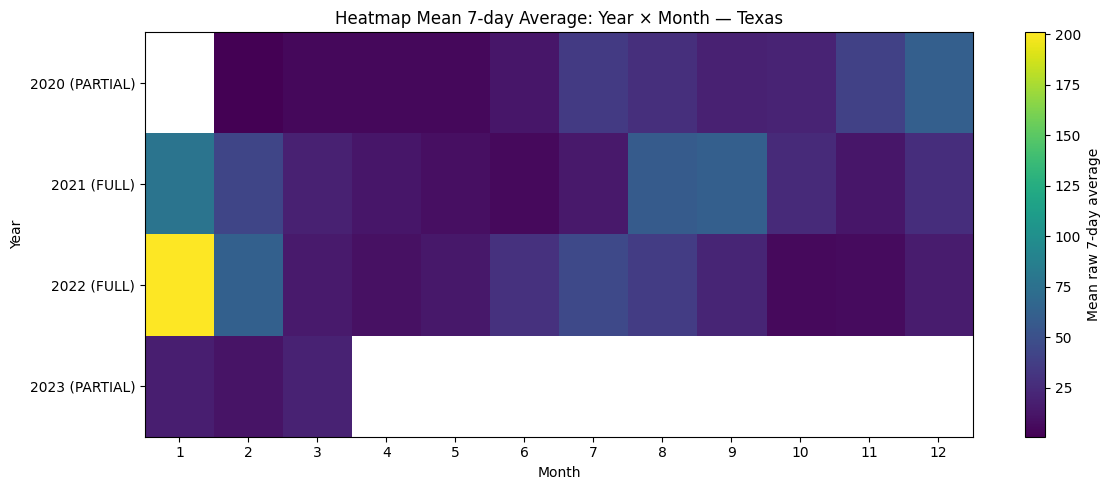

Nhận xét: heatmap cho phép nhận diện tháng/wave nổi bật và đồng thời cho thấy rõ những tháng không tồn tại ở các năm PARTIAL.


In [ ]:
heat_year_month = seasonal_summary.pivot(
    index="year",
    columns="month_of_year",
    values="mean_7d_avg"
)

plt.figure(figsize=(12, 5))
masked = np.ma.masked_invalid(heat_year_month.values)
im = plt.imshow(masked, aspect="auto")
plt.colorbar(im, label="Mean raw 7-day average")
plt.yticks(
    range(len(heat_year_month.index)),
    [
        f"{int(y)} ({'FULL' if y in full_years else 'PARTIAL'})"
        for y in heat_year_month.index
    ]
)
plt.xticks(
    range(12),
    range(1, 13)
)
plt.title(f"Heatmap Mean 7-day Average: Year × Month — {TARGET_STATE}")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

print(
    "Nhận xét: heatmap cho phép nhận diện tháng/wave nổi bật và đồng thời "
    "cho thấy rõ những tháng không tồn tại ở các năm PARTIAL."
)


### 9.3.7 Kiểm định thống kê: các năm đầy đủ có khác nhau không?

Để giảm phụ thuộc chuỗi thời gian, trước hết nhóm dữ liệu thành **county-year**, lấy median `new_cases_7d_avg_raw` của mỗi county trong từng năm.

- Nếu có đúng **2 năm đầy đủ**, dùng **Wilcoxon signed-rank test** trên các county xuất hiện ở cả hai năm.
- Nếu có **≥3 năm đầy đủ**, dùng **Friedman test** cho thiết kế lặp theo county.
- `p < 0.05` cho thấy có bằng chứng rằng phân phối giữa các năm khác nhau, nhưng **p-value không nói mức khác biệt lớn hay nhỏ**. Vì vậy notebook cũng tính median paired difference.

Đây phù hợp hơn việc đưa toàn bộ hàng ngày vào Kruskal-Wallis vì các observation theo thời gian của cùng một county không độc lập hoàn toàn.


In [ ]:
# ============================================================
# 9.3.7 PAIRED YEAR COMPARISON AT COUNTY LEVEL
# ============================================================
from scipy.stats import wilcoxon, friedmanchisquare

county_year = (
    annual_df[
        annual_df["year"].isin(full_years)
    ]
    .groupby(["county", "year"], as_index=False)
    .agg(
        county_year_median_7d=(
            "new_cases_7d_avg_raw", "median"
        ),
        county_year_mean_7d=(
            "new_cases_7d_avg_raw", "mean"
        ),
        observed_days=("date", "nunique")
    )
)

display(county_year.head())

if len(full_years) < 2:
    print(
        "Không có ít nhất 2 năm FULL để kiểm định so sánh công bằng."
    )

elif len(full_years) == 2:
    y1, y2 = sorted(full_years)

    paired = (
        county_year[
            county_year["year"].isin([y1, y2])
        ]
        .pivot(
            index="county",
            columns="year",
            values="county_year_median_7d"
        )
        .dropna()
    )

    print(f"Số county có dữ liệu ở cả {y1} và {y2}: {len(paired)}")

    if len(paired) >= 5:
        stat, p_value = wilcoxon(
            paired[y1],
            paired[y2],
            alternative="two-sided",
            zero_method="wilcox"
        )

        diff = paired[y2] - paired[y1]

        print(f"Wilcoxon statistic = {stat:.4f}")
        print(f"p-value = {p_value:.6g}")
        print(
            f"Median county-level difference ({y2} - {y1}) = "
            f"{diff.median():.3f}"
        )
        print(
            f"County cao hơn ở {y2}: {(diff > 0).mean()*100:.2f}% | "
            f"thấp hơn: {(diff < 0).mean()*100:.2f}% | "
            f"bằng nhau: {(diff == 0).mean()*100:.2f}%."
        )

        alpha = 0.05
        if p_value < alpha:
            print(
                f"Kết luận thống kê: p < {alpha}; có bằng chứng cho thấy "
                f"county-level median 7-day average giữa {y1} và {y2} khác nhau."
            )
        else:
            print(
                f"Kết luận thống kê: p >= {alpha}; chưa có đủ bằng chứng "
                f"để kết luận hai năm khác nhau ở mức ý nghĩa {alpha}."
            )
    else:
        print("Không đủ county ghép cặp để chạy Wilcoxon đáng tin cậy.")

else:
    full_years_sorted = sorted(full_years)

    wide = (
        county_year[
            county_year["year"].isin(full_years_sorted)
        ]
        .pivot(
            index="county",
            columns="year",
            values="county_year_median_7d"
        )
        .dropna()
    )

    print(
        f"Số county có mặt ở tất cả {len(full_years_sorted)} năm FULL: "
        f"{len(wide)}"
    )

    if len(wide) >= 5:
        samples = [
            wide[y].values
            for y in full_years_sorted
        ]

        stat, p_value = friedmanchisquare(*samples)

        print(f"Friedman statistic = {stat:.4f}")
        print(f"p-value = {p_value:.6g}")

        alpha = 0.05
        if p_value < alpha:
            print(
                f"Kết luận thống kê: p < {alpha}; ít nhất một năm FULL "
                "có phân phối county-level khác các năm còn lại."
            )
        else:
            print(
                f"Kết luận thống kê: p >= {alpha}; chưa đủ bằng chứng "
                "cho thấy các năm FULL khác nhau."
            )
    else:
        print("Không đủ county hoàn chỉnh để chạy Friedman test.")

county_year.to_csv(
    OUTPUT_DIR / f"county_year_statistics_{safe_state}.csv",
    index=False
)


,county,year,county_year_median_7d,county_year_mean_7d,observed_days
0,Anderson,2021,3.86,10.52,365
1,Anderson,2022,3.00,6.97,365
2,Andrews,2021,2.14,4.55,365
3,Andrews,2022,2.14,5.11,365
4,Angelina,2021,10.14,23.75,365


Số county có dữ liệu ở cả 2021 và 2022: 254
Wilcoxon statistic = 8433.5000
p-value = 3.59054e-06
Median county-level difference (2022 - 2021) = -0.143
County cao hơn ở 2022: 28.74% | thấp hơn: 61.02% | bằng nhau: 10.24%.
Kết luận thống kê: p < 0.05; có bằng chứng cho thấy county-level median 7-day average giữa 2021 và 2022 khác nhau.


### 9.3.8 Biểu đồ thay đổi theo county giữa hai năm đầy đủ

Nếu có đúng hai năm đầy đủ, biểu đồ scatter đặt mỗi county thành một điểm:

- nằm **trên** đường `y = x`: mức median ở năm sau cao hơn;
- nằm **dưới** đường `y = x`: mức median ở năm sau thấp hơn.

Biểu đồ này bổ sung cho p-value vì cho thấy mức thay đổi thực tế giữa các county.


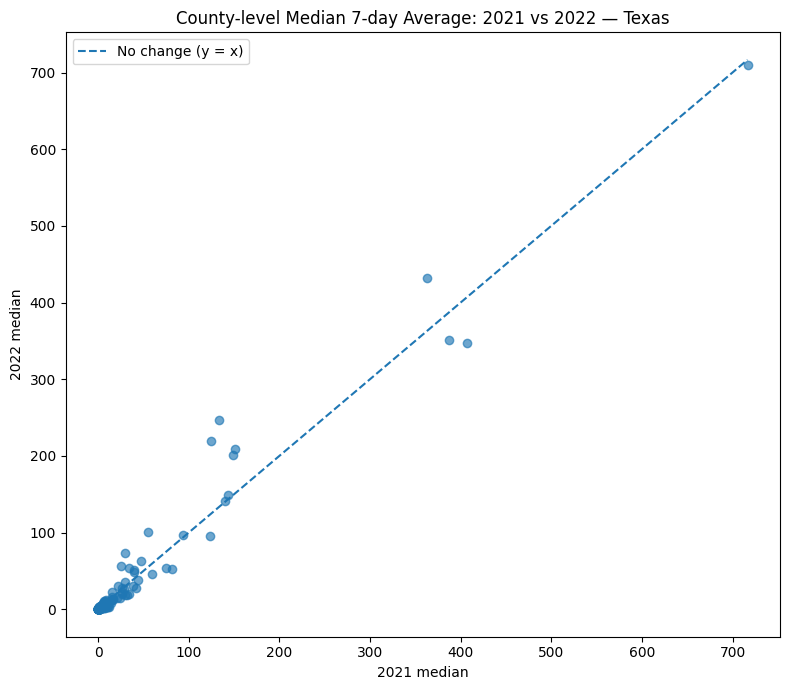

Top 5 county tăng nhiều nhất từ 2021 → 2022:


,difference
county,
Hidalgo,114.29
Travis,95.00
Bexar,69.29
Fort Bend,58.57
Collin,51.57


Top 5 county giảm nhiều nhất từ 2021 → 2022:


,difference
county,
Tarrant,-58.86
Dallas,-36.29
Brazoria,-28.71
Montgomery,-27.86
Galveston,-21.00


In [ ]:
if len(full_years) == 2:
    y1, y2 = sorted(full_years)

    paired_plot = (
        county_year[
            county_year["year"].isin([y1, y2])
        ]
        .pivot(
            index="county",
            columns="year",
            values="county_year_median_7d"
        )
        .dropna()
    )

    if len(paired_plot) > 0:
        plt.figure(figsize=(8, 7))
        plt.scatter(
            paired_plot[y1],
            paired_plot[y2],
            alpha=0.65
        )

        min_v = min(
            paired_plot[y1].min(),
            paired_plot[y2].min()
        )
        max_v = max(
            paired_plot[y1].max(),
            paired_plot[y2].max()
        )

        plt.plot(
            [min_v, max_v],
            [min_v, max_v],
            linestyle="--",
            label="No change (y = x)"
        )

        plt.title(
            f"County-level Median 7-day Average: {y1} vs {y2} — {TARGET_STATE}"
        )
        plt.xlabel(f"{y1} median")
        plt.ylabel(f"{y2} median")
        plt.legend()
        plt.tight_layout()
        plt.show()

        diff = paired_plot[y2] - paired_plot[y1]

        biggest_up = diff.nlargest(5)
        biggest_down = diff.nsmallest(5)

        print(f"Top 5 county tăng nhiều nhất từ {y1} → {y2}:")
        display(
            biggest_up.rename("difference").to_frame()
        )

        print(f"Top 5 county giảm nhiều nhất từ {y1} → {y2}:")
        display(
            biggest_down.rename("difference").to_frame()
        )
else:
    print(
        "Biểu đồ pairwise tự động chỉ chạy khi có đúng 2 năm FULL."
    )


### 9.3.9 Kết luận về việc dùng 1 năm hay nhiều năm

Phần Data Understanding **không tự quyết định** train một năm hay nhiều năm. Nó tạo bằng chứng để bước Modeling kiểm tra.

Quy tắc đề xuất:

- **EDA:** giữ toàn bộ các năm để hiểu lịch sử và concept drift.
- **So sánh năm:** ưu tiên các năm FULL.
- **Modeling:** thử nhiều `training window` trên **cùng một test period**, sau đó chọn theo MAE/RMSE/R².


In [ ]:
# Candidate modeling windows — chỉ là kế hoạch, chưa train model
modeling_window_plan = []

if len(full_years) >= 1:
    full_years_sorted = sorted(full_years)

    # 1-year windows
    for y in full_years_sorted:
        modeling_window_plan.append({
            "candidate": f"1-year: {y}",
            "train_start": f"{y}-01-01",
            "train_end": f"{y}-12-31",
            "note": "Single complete year"
        })

    # Expanding/full multi-year window
    if len(full_years_sorted) >= 2:
        modeling_window_plan.append({
            "candidate": (
                f"Multi-year: {full_years_sorted[0]}-"
                f"{full_years_sorted[-1]}"
            ),
            "train_start": f"{full_years_sorted[0]}-01-01",
            "train_end": f"{full_years_sorted[-1]}-12-31",
            "note": "Multiple complete years"
        })

modeling_window_plan = pd.DataFrame(modeling_window_plan)
display(modeling_window_plan)

print(
    "Khi Modeling, các candidate window phải được đánh giá trên cùng test set "
    "và cùng feature/model để kết luận nhiều năm có tốt hơn một năm hay không."
)

modeling_window_plan.to_csv(
    OUTPUT_DIR / f"candidate_training_windows_{safe_state}.csv",
    index=False
)


,candidate,train_start,train_end,note
0,1-year: 2021,2021-01-01,2021-12-31,Single complete year
1,1-year: 2022,2022-01-01,2022-12-31,Single complete year
2,Multi-year: 2021-2022,2021-01-01,2022-12-31,Multiple complete years


Khi Modeling, các candidate window phải được đánh giá trên cùng test set và cùng feature/model để kết luận nhiều năm có tốt hơn một năm hay không.


## 10. Trực quan hóa EDA

Các biểu đồ sau dùng để mô tả **quy mô, xu hướng, phân phối và mối liên hệ sơ bộ**.

> Những nhận xét dưới biểu đồ được tạo từ số liệu thực tế khi notebook chạy. Chúng là nguyên liệu để viết báo cáo, không phải kết luận nhân quả.


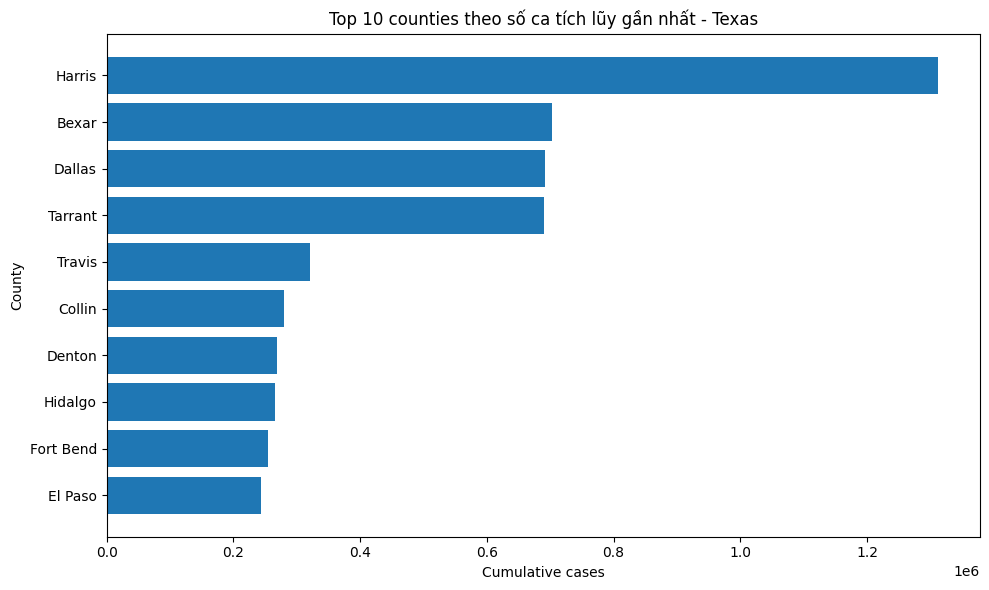

Nhận xét 1: Harris có số ca tích lũy cao nhất trong snapshot cuối với 1,312,744 ca.
Nhận xét 2: chênh lệch giữa hạng 1 và hạng 2 là 609,178 ca.
Lưu ý: raw cumulative counts phản ánh quy mô tuyệt đối, chưa chuẩn hóa theo dân số.


In [ ]:
# Chỉ dùng county có tên xác định cho so sánh địa lý
df_geo = df_focus[
    df_focus["county"].notna() &
    ~focus_unknown_mask
].copy()

latest_rows = (
    df_geo.dropna(subset=["date", "county"])
    .sort_values("date")
    .groupby("county", as_index=False)
    .tail(1)
)

top_latest = latest_rows.nlargest(TOP_N_COUNTIES, "cases").sort_values("cases")

plt.figure(figsize=(10, 6))
plt.barh(top_latest["county"], top_latest["cases"])
plt.title(f"Top {TOP_N_COUNTIES} counties theo số ca tích lũy gần nhất - {TARGET_STATE}")
plt.xlabel("Cumulative cases")
plt.ylabel("County")
plt.tight_layout()
plt.show()

if len(top_latest):
    top_row = top_latest.iloc[-1]
    print(
        f"Nhận xét 1: {top_row['county']} có số ca tích lũy cao nhất trong snapshot cuối "
        f"với {top_row['cases']:,.0f} ca."
    )
    if len(top_latest) >= 2:
        second = top_latest.iloc[-2]
        print(
            f"Nhận xét 2: chênh lệch giữa hạng 1 và hạng 2 là "
            f"{top_row['cases'] - second['cases']:,.0f} ca."
        )
print("Lưu ý: raw cumulative counts phản ánh quy mô tuyệt đối, chưa chuẩn hóa theo dân số.")


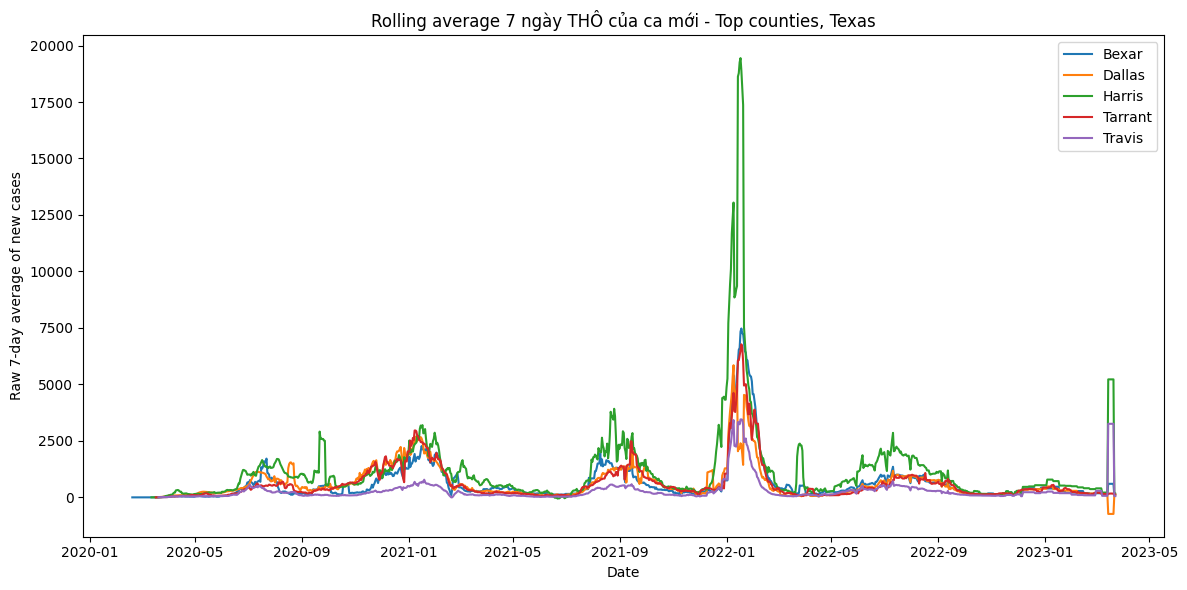

Nhận xét 1: trong 5 county hiển thị, rolling average thô đạt đỉnh 19,442.29 ca/ngày tại Harris vào 2022-01-17.
Nhận xét 2: đường 7 ngày làm mượt biến động ngày, nhưng hiện vẫn chịu ảnh hưởng của reporting corrections.


In [ ]:
line_counties = latest_rows.nlargest(5, "cases")["county"].tolist()
line_df = df_geo[df_geo["county"].isin(line_counties)].copy()

plt.figure(figsize=(12, 6))
for county, g in line_df.groupby("county"):
    plt.plot(g["date"], g["new_cases_7d_avg_raw"], label=county)

plt.title(f"Rolling average 7 ngày THÔ của ca mới - Top counties, {TARGET_STATE}")
plt.xlabel("Date")
plt.ylabel("Raw 7-day average of new cases")
plt.legend()
plt.tight_layout()
plt.show()

peak = (
    line_df.dropna(subset=["new_cases_7d_avg_raw"])
    .sort_values("new_cases_7d_avg_raw", ascending=False)
    .head(1)
)
if len(peak):
    r = peak.iloc[0]
    print(
        f"Nhận xét 1: trong 5 county hiển thị, rolling average thô đạt đỉnh "
        f"{r['new_cases_7d_avg_raw']:,.2f} ca/ngày tại {r['county']} "
        f"vào {r['date'].date()}."
    )
print("Nhận xét 2: đường 7 ngày làm mượt biến động ngày, nhưng hiện vẫn chịu ảnh hưởng của reporting corrections.")


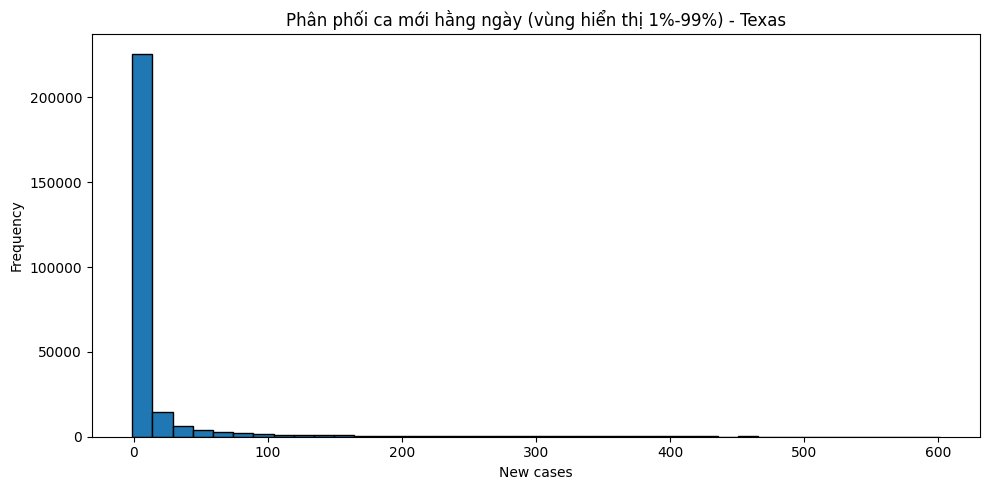

Nhận xét 1: vùng hiển thị 1%-99% là -1.00 đến 601.00 ca/ngày.
Nhận xét 2: median = 0.00, mean = 30.89, skewness = 90.98; dùng các số này để mô tả độ lệch phân phối.


In [ ]:
s = df_geo["new_cases"].dropna()

if len(s) > 0:
    q01, q99 = s.quantile([0.01, 0.99])
    s_view = s[(s >= q01) & (s <= q99)]

    plt.figure(figsize=(10, 5))
    plt.hist(s_view, bins=40, edgecolor="black")
    plt.title(f"Phân phối ca mới hằng ngày (vùng hiển thị 1%-99%) - {TARGET_STATE}")
    plt.xlabel("New cases")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    print(f"Nhận xét 1: vùng hiển thị 1%-99% là {q01:,.2f} đến {q99:,.2f} ca/ngày.")
    print(
        f"Nhận xét 2: median = {s.median():,.2f}, mean = {s.mean():,.2f}, "
        f"skewness = {s.skew():,.2f}; dùng các số này để mô tả độ lệch phân phối."
    )


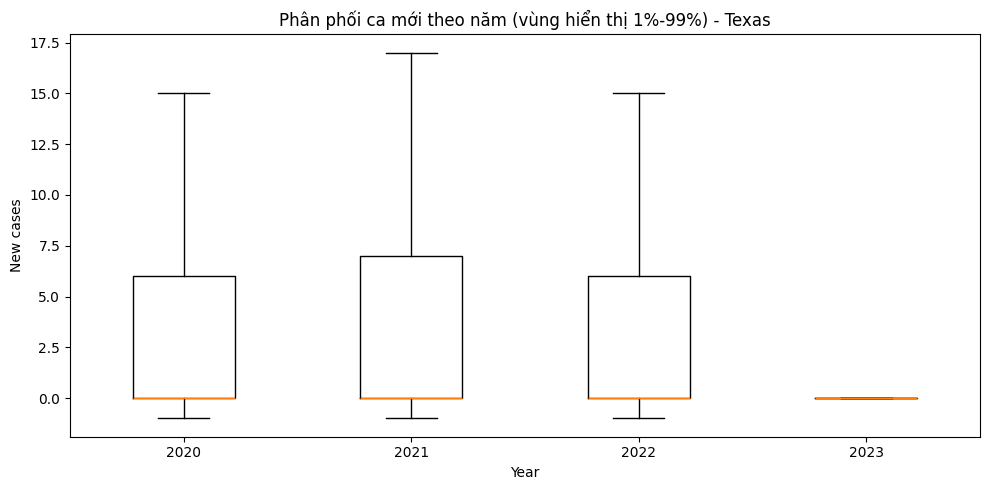

,median,q1,q3,IQR
year,,,,
2020,0.00,0.00,6.00,6.00
2021,0.00,0.00,7.00,7.00
2022,0.00,0.00,7.00,7.00
2023,0.00,0.00,0.00,0.00


Nhận xét 1: năm có median new_cases cao nhất là 2020 với median 0.00.
Nhận xét 2: năm có IQR lớn nhất là 2021 (7.00), cho thấy mức biến động giữa các quan sát lớn hơn.


In [ ]:
box_df = df_geo.dropna(subset=["date", "new_cases"]).copy()
box_df["year"] = box_df["date"].dt.year

if len(box_df) > 0:
    lo, hi = box_df["new_cases"].quantile([0.01, 0.99])
    box_view = box_df[box_df["new_cases"].between(lo, hi)]

    years = sorted(box_view["year"].unique())
    data = [box_view.loc[box_view["year"] == y, "new_cases"].values for y in years]

    plt.figure(figsize=(10, 5))
    plt.boxplot(data, tick_labels=years, showfliers=False)
    plt.title(f"Phân phối ca mới theo năm (vùng hiển thị 1%-99%) - {TARGET_STATE}")
    plt.xlabel("Year")
    plt.ylabel("New cases")
    plt.tight_layout()
    plt.show()

    annual_stats = (
        box_df.groupby("year")["new_cases"]
        .agg(median="median",
             q1=lambda s: s.quantile(0.25),
             q3=lambda s: s.quantile(0.75))
    )
    annual_stats["IQR"] = annual_stats["q3"] - annual_stats["q1"]
    display(annual_stats)

    highest_med_year = annual_stats["median"].idxmax()
    print(
        f"Nhận xét 1: năm có median new_cases cao nhất là {highest_med_year} "
        f"với median {annual_stats.loc[highest_med_year, 'median']:,.2f}."
    )
    highest_iqr_year = annual_stats["IQR"].idxmax()
    print(
        f"Nhận xét 2: năm có IQR lớn nhất là {highest_iqr_year} "
        f"({annual_stats.loc[highest_iqr_year, 'IQR']:,.2f}), "
        "cho thấy mức biến động giữa các quan sát lớn hơn."
    )


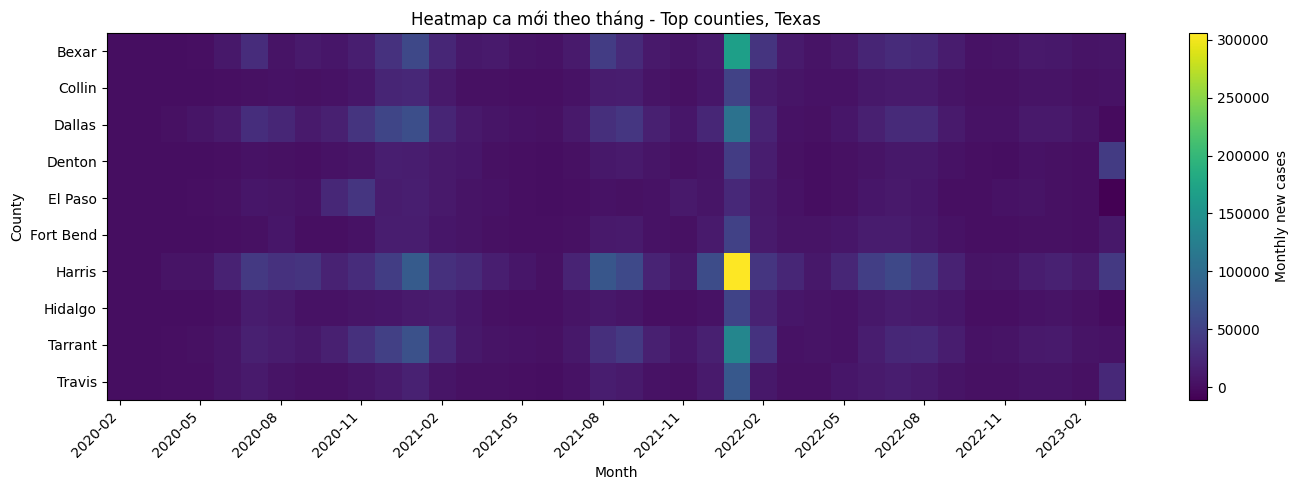

Nhận xét 1: trong nhóm county hiển thị, tổng ca mới tháng cao nhất là 306,063 tại Harris vào 2022-01.
Nhận xét 2: xét tổng nhóm top counties, tháng nổi bật nhất là 2022-01 với 1,017,602 ca mới.


In [ ]:
heat_counties = latest_rows.nlargest(TOP_N_COUNTIES, "cases")["county"].tolist()
heat = df_geo[df_geo["county"].isin(heat_counties)].copy()
heat["month"] = heat["date"].dt.to_period("M").astype(str)

heat_pivot = heat.pivot_table(
    index="county",
    columns="month",
    values="new_cases",
    aggfunc="sum"
)

if not heat_pivot.empty:
    plt.figure(figsize=(14, max(5, len(heat_pivot) * 0.45)))
    im = plt.imshow(heat_pivot.fillna(0).values, aspect="auto")
    plt.colorbar(im, label="Monthly new cases")
    plt.yticks(range(len(heat_pivot.index)), heat_pivot.index)

    step = max(1, len(heat_pivot.columns) // 12)
    tick_idx = list(range(0, len(heat_pivot.columns), step))
    plt.xticks(
        tick_idx,
        [heat_pivot.columns[i] for i in tick_idx],
        rotation=45,
        ha="right"
    )

    plt.title(f"Heatmap ca mới theo tháng - Top counties, {TARGET_STATE}")
    plt.xlabel("Month")
    plt.ylabel("County")
    plt.tight_layout()
    plt.show()

    stacked = heat_pivot.stack().dropna()
    if len(stacked):
        peak_key = stacked.idxmax()
        peak_val = stacked.max()
        print(
            f"Nhận xét 1: trong nhóm county hiển thị, tổng ca mới tháng cao nhất là "
            f"{peak_val:,.0f} tại {peak_key[0]} vào {peak_key[1]}."
        )

    month_totals = heat.groupby("month")["new_cases"].sum(min_count=1)
    if len(month_totals.dropna()):
        peak_month = month_totals.idxmax()
        print(
            f"Nhận xét 2: xét tổng nhóm top counties, tháng nổi bật nhất là "
            f"{peak_month} với {month_totals.loc[peak_month]:,.0f} ca mới."
        )


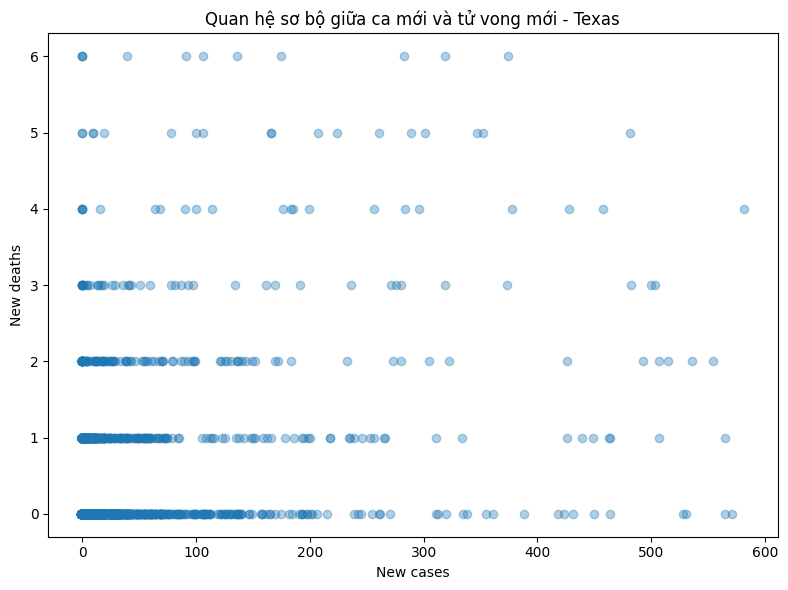

Nhận xét 1: Pearson correlation cùng ngày = 0.297.
Nhận xét 2: không diễn giải correlation thành nhân quả; tử vong thường có độ trễ so với ca mắc.


In [ ]:
scatter = df_geo[["new_cases", "new_deaths"]].dropna().copy()

if len(scatter) > 0:
    xlo, xhi = scatter["new_cases"].quantile([0.01, 0.99])
    ylo, yhi = scatter["new_deaths"].quantile([0.01, 0.99])

    view = scatter[
        scatter["new_cases"].between(xlo, xhi) &
        scatter["new_deaths"].between(ylo, yhi)
    ]

    if len(view) > 5000:
        view = view.sample(5000, random_state=42)

    plt.figure(figsize=(8, 6))
    plt.scatter(view["new_cases"], view["new_deaths"], alpha=0.35)
    plt.title(f"Quan hệ sơ bộ giữa ca mới và tử vong mới - {TARGET_STATE}")
    plt.xlabel("New cases")
    plt.ylabel("New deaths")
    plt.tight_layout()
    plt.show()

    corr_same_day = scatter[["new_cases", "new_deaths"]].corr().iloc[0, 1]
    print(f"Nhận xét 1: Pearson correlation cùng ngày = {corr_same_day:.3f}.")
    print("Nhận xét 2: không diễn giải correlation thành nhân quả; tử vong thường có độ trễ so với ca mắc.")


### 10.7 Khám phá độ trễ giữa ca mắc và tử vong

Đây chỉ là EDA/Diagnostic sơ bộ. Ta so `new_cases(t)` với `new_deaths(t+7/t+14/t+21)` trong cùng county.

Nếu correlation ở lag dương cao hơn cùng ngày, điều đó gợi ý nên đưa yếu tố thời gian vào phân tích tiếp theo.


In [ ]:
lag_base = df_geo.sort_values(["county", "date"]).copy()

lag_results = []
for lag in [0, 7, 14, 21]:
    if lag == 0:
        tmp = lag_base[["new_cases", "new_deaths"]].dropna()
        corr = tmp.corr().iloc[0, 1] if len(tmp) > 1 else np.nan
    else:
        future_deaths = (
            lag_base.groupby("county")["new_deaths"].shift(-lag)
        )
        tmp = pd.DataFrame({
            "new_cases": lag_base["new_cases"],
            "future_deaths": future_deaths
        }).dropna()
        corr = tmp.corr().iloc[0, 1] if len(tmp) > 1 else np.nan

    lag_results.append({
        "death_lag_days": lag,
        "pearson_corr": corr,
        "n_pairs": len(tmp)
    })

lag_corr = pd.DataFrame(lag_results)
display(lag_corr)

valid_lags = lag_corr.dropna(subset=["pearson_corr"])
if len(valid_lags):
    best = valid_lags.loc[valid_lags["pearson_corr"].abs().idxmax()]
    print(
        f"Nhận xét: trong các lag kiểm tra, |correlation| lớn nhất tại lag "
        f"{int(best['death_lag_days'])} ngày với r = {best['pearson_corr']:.3f}."
    )
    print("Đây vẫn chỉ là association, không phải bằng chứng nhân quả.")


,death_lag_days,pearson_corr,n_pairs
0,0,0.30,273084
1,7,0.30,271299
2,14,0.35,269514
3,21,0.36,267729


Nhận xét: trong các lag kiểm tra, |correlation| lớn nhất tại lag 21 ngày với r = 0.356.
Đây vẫn chỉ là association, không phải bằng chứng nhân quả.


### 10.8 Phân tích xu hướng theo tháng

Thay vì chỉ nhìn từng ngày, tổng hợp theo tháng giúp nhận diện các **wave** lớn rõ hơn. Ở đây vẫn dùng dữ liệu sai phân thô nên các reporting corrections được giữ nguyên; mục đích là Data Understanding, chưa phải số liệu đã hiệu chỉnh cuối cùng.


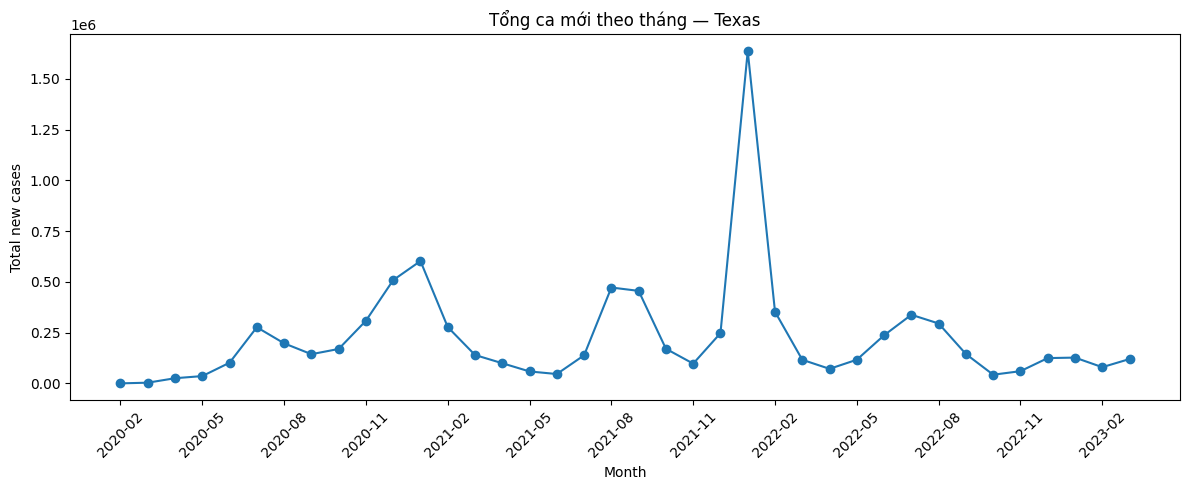

Nhận xét: tháng có tổng new_cases lớn nhất là 2022-01 với 1,636,711 ca mới theo sai phân thô.
Lưu ý: 2023 chỉ có dữ liệu đến tháng 3 và không nên được so sánh như một năm hoàn chỉnh.


In [ ]:
monthly_epi = df_focus_analysis.copy()
monthly_epi["month"] = monthly_epi["date"].dt.to_period("M").astype(str)

monthly_epi = (
    monthly_epi.groupby("month", as_index=False)
    .agg(
        total_new_cases=("new_cases", "sum"),
        total_new_deaths=("new_deaths", "sum"),
        mean_7d_avg=("new_cases_7d_avg_raw", "mean")
    )
)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_epi["month"],
    monthly_epi["total_new_cases"],
    marker="o"
)
plt.title(f"Tổng ca mới theo tháng — {TARGET_STATE}")
plt.xlabel("Month")
plt.ylabel("Total new cases")
step = max(1, len(monthly_epi)//12)
plt.xticks(
    range(0, len(monthly_epi), step),
    monthly_epi["month"].iloc[::step],
    rotation=45
)
plt.tight_layout()
plt.show()

peak_month = monthly_epi.loc[
    monthly_epi["total_new_cases"].idxmax()
]
print(
    f"Nhận xét: tháng có tổng new_cases lớn nhất là {peak_month['month']} "
    f"với {peak_month['total_new_cases']:,.0f} ca mới theo sai phân thô."
)
print(
    "Lưu ý: 2023 chỉ có dữ liệu đến tháng 3 và không nên được so sánh như một năm hoàn chỉnh."
)


### 10.9 Phân tích theo thứ trong tuần

Phân tích day-of-week giúp phát hiện **reporting pattern**. Nếu số liệu có chênh lệch có hệ thống giữa các ngày trong tuần, đây có thể là đặc điểm của quy trình báo cáo chứ không hoàn toàn là đặc điểm dịch tễ.


,mean,median,count
day_of_week,,,
Monday,35.26,0.00,38993
Tuesday,34.64,1.00,39009
Wednesday,44.30,3.00,39049
Thursday,30.81,1.00,39115
Friday,34.67,1.00,38901
Saturday,20.97,0.00,38949
Sunday,15.63,0.00,38979


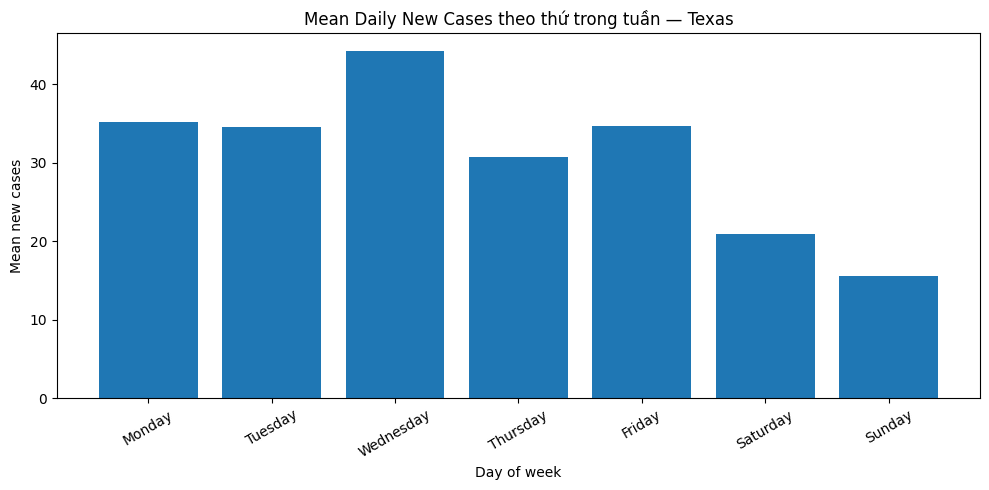

Nhận xét: mean new_cases cao nhất vào Wednesday và thấp nhất vào Sunday. Nếu chênh lệch đáng kể, cần cân nhắc hiệu ứng lịch báo cáo khi feature engineering.


In [ ]:
dow_df = df_focus_analysis.dropna(subset=["date", "new_cases"]).copy()
dow_df["day_of_week"] = dow_df["date"].dt.day_name()

dow_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

dow_summary = (
    dow_df.groupby("day_of_week")["new_cases"]
    .agg(mean="mean", median="median", count="size")
    .reindex(dow_order)
)

display(dow_summary)

plt.figure(figsize=(10, 5))
plt.bar(dow_summary.index, dow_summary["mean"])
plt.title(f"Mean Daily New Cases theo thứ trong tuần — {TARGET_STATE}")
plt.xlabel("Day of week")
plt.ylabel("Mean new cases")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

max_day = dow_summary["mean"].idxmax()
min_day = dow_summary["mean"].idxmin()
print(
    f"Nhận xét: mean new_cases cao nhất vào {max_day} và thấp nhất vào {min_day}. "
    "Nếu chênh lệch đáng kể, cần cân nhắc hiệu ứng lịch báo cáo khi feature engineering."
)


## 11. Đối chiếu county-level với `us-states.csv`

Đây là **sanity check**. Tổng county có thể khác state-level do `Unknown`, khác biệt địa lý báo cáo hoặc quy tắc tổng hợp. Chênh lệch không tự động là lỗi.


In [ ]:
if df_states_raw is not None:
    st = df_states_raw.copy()
    st["date"] = pd.to_datetime(st["date"], errors="coerce")
    st_focus = st[st["state"].eq(TARGET_STATE)].copy()

    if not st_focus.empty and not df_focus.empty:
        common_date = min(st_focus["date"].max(), df_focus["date"].max())
        state_row = st_focus[st_focus["date"].eq(common_date)]
        county_rows = df_focus[df_focus["date"].eq(common_date)]

        if not state_row.empty:
            state_cases = state_row["cases"].iloc[-1]
            county_sum = county_rows["cases"].sum()

            print("Ngày đối chiếu:", common_date.date())
            print("State-level cases:", f"{state_cases:,.0f}")
            print("Sum county cases :", f"{county_sum:,.0f}")
            print("Chênh lệch       :", f"{county_sum - state_cases:,.0f}")
else:
    print("Không có us-states.csv - bỏ qua bước đối chiếu.")


Ngày đối chiếu: 2023-03-23
State-level cases: 8,447,168
Sum county cases : 8,447,233
Chênh lệch       : 65


### Nhận xét Sanity Check

Ở ngày đối chiếu 23/03/2023, state-level ghi nhận **8.447.168 ca**, trong khi tổng county là **8.447.233 ca**, chỉ chênh **65 ca**. Sai khác rất nhỏ so với tổng quy mô hơn 8,4 triệu ca, cho thấy hai cấp dữ liệu nhìn chung nhất quán.

Tuy nhiên không nên ép tổng county phải khớp state-level tuyệt đối, vì các nhãn địa lý kỹ thuật hoặc khác biệt quy tắc tổng hợp có thể tạo chênh lệch nhỏ.


## 12. Đánh giá mức độ phù hợp và hạn chế của dữ liệu

### Phù hợp

- Có daily county-level data trong nhiều năm.
- Có thể tạo biến sai phân, lag, growth và target dự báo sau này.
- Có thể đối chiếu với state-level data.

### Hạn chế cần ghi trong báo cáo

1. `cases`/`deaths` là dữ liệu được **báo cáo**, không đồng nghĩa toàn bộ số nhiễm thực tế.
2. Có reporting corrections làm daily increments âm.
3. County khác nhau mạnh về quy mô dân số.
4. **Raw count không đủ để so sánh rủi ro công bằng giữa county.**
5. Nếu muốn `cases per 100k`, cần bổ sung population theo county hoặc sử dụng một nguồn đã chuẩn hóa.
6. Dữ liệu lịch sử không mặc định đại diện hoàn toàn cho một đợt dịch tương lai; cần time-based validation khi Modeling.


### Tổng hợp các phát hiện chính trước Data Preparation

Từ các kết quả đã chạy và các phân tích bổ sung, có thể rút ra:

- dữ liệu county nhiều năm đủ lớn để tiếp tục phân tích;
- missing tổng thể thấp nhưng có cấu trúc địa lý, đặc biệt ở FIPS/nhãn không xác định;
- cần loại **technical county labels** khỏi phân tích địa lý;
- coverage của phần lớn county tốt nhưng không đồng đều;
- daily differences chứa reporting corrections âm;
- phân phối `new_cases` lệch mạnh, nên dùng median/IQR song song mean/std;
- raw case counts hữu ích cho **khối lượng tuyệt đối**, nhưng chưa đủ để so sánh **rủi ro** giữa county;
- cần population/per-100k trước khi xây Priority Score hoặc phân bổ nguồn lực;
- khoảng thời gian train phải được lựa chọn bằng **time-based validation**, không chọn vì “càng nhiều năm càng tốt”.


## 13. Nhận xét tự động sau Data Understanding


In [ ]:
summary = []

summary.append(f"### Tóm tắt Data Understanding — {TARGET_STATE}")
summary.append(f"- Nguồn county: **{COUNTY_SOURCE}**.")
summary.append(
    f"- Toàn bộ nguồn sau giới hạn thời gian có **{len(df_county):,} dòng**, "
    f"{df_county.shape[1]} cột, từ **{df_county['date'].min().date()}** "
    f"đến **{df_county['date'].max().date()}**."
)
summary.append(
    f"- Bang phân tích sâu: **{TARGET_STATE}**; cách chọn: **{STATE_SELECTION_REASON}**."
)
summary.append(
    f"- Phạm vi {TARGET_STATE}: **{len(df_focus):,} dòng**, "
    f"**{df_focus['county'].nunique()} county labels**, "
    f"giai đoạn **{df_focus['date'].min().date()} → {df_focus['date'].max().date()}**."
)
summary.append(
    f"- Riêng {TARGET_STATE}: thiếu FIPS **{int(df_focus['fips'].isna().sum()):,} dòng**; "
    f"`Unknown` **{int(focus_unknown_mask.sum()):,} dòng**."
)
summary.append(
    f"- Phát hiện **{int(df_focus['new_cases_negative'].sum()):,}** lần `new_cases < 0` "
    f"và **{int(df_focus['new_deaths_negative'].sum()):,}** lần `new_deaths < 0`; "
    "không tự sửa ở Data Understanding."
)

if len(coverage):
    summary.append(
        f"- Internal coverage trung vị: **{coverage['internal_coverage_pct'].median():.2f}%**; "
        f"Study-window coverage trung vị: **{coverage['study_window_coverage_pct'].median():.2f}%**."
    )

summary.append(
    "- `new_cases_7d_avg_raw` chỉ dùng EDA vì vẫn có thể chứa ảnh hưởng của reporting corrections."
)
summary.append(
    "- Raw counts phản ánh quy mô tuyệt đối; để so sánh rủi ro giữa county cần population/per-100k ở Data Preparation."
)
summary.append(
    "- Việc chọn 1 năm hay nhiều năm để train chưa được quyết định ở đây; phải so sánh bằng time-based validation."
)

summary_md = "\n".join(summary)
display(Markdown(summary_md))

with open(OUTPUT_DIR / "data_understanding_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_md.replace("**", ""))


### Tóm tắt Data Understanding — Texas
- Nguồn county: **us-counties-2020.csv + us-counties-2021.csv + us-counties-2022.csv + us-counties-2023.csv**.
- Toàn bộ nguồn sau giới hạn thời gian có **3,525,161 dòng**, 6 cột, từ **2020-01-21** đến **2023-03-23**.
- Bang phân tích sâu: **Texas**; cách chọn: **auto_eligible**.
- Phạm vi Texas: **273,458 dòng**, **256 county labels**, giai đoạn **2020-02-12 → 2023-03-23**.
- Riêng Texas: thiếu FIPS **119 dòng**; `Unknown` **119 dòng**.
- Phát hiện **3,678** lần `new_cases < 0` và **420** lần `new_deaths < 0`; không tự sửa ở Data Understanding.
- Internal coverage trung vị: **100.00%**; Study-window coverage trung vị: **95.69%**.
- `new_cases_7d_avg_raw` chỉ dùng EDA vì vẫn có thể chứa ảnh hưởng của reporting corrections.
- Raw counts phản ánh quy mô tuyệt đối; để so sánh rủi ro giữa county cần population/per-100k ở Data Preparation.
- Việc chọn 1 năm hay nhiều năm để train chưa được quyết định ở đây; phải so sánh bằng time-based validation.

## 14. Xuất dữ liệu phục vụ bước Data Preparation

File xuất vẫn là **Data Understanding output**, chưa phải dataset cuối để train.


In [ ]:
export_cols = [
    c for c in [
        "date", "county", "state", "fips", "cases", "deaths",
        "new_cases", "new_deaths", "new_cases_7d_avg_raw",
        "new_cases_negative", "new_deaths_negative"
    ]
    if c in df_focus.columns
]

export_path = OUTPUT_DIR / f"{safe_state}_data_understanding.csv"
df_focus[export_cols].to_csv(export_path, index=False)

global_missing_table.to_csv(OUTPUT_DIR / "missing_summary_global.csv")
focus_missing_table.to_csv(OUTPUT_DIR / f"missing_summary_{safe_state}.csv")
state_profile.to_csv(OUTPUT_DIR / "state_profile.csv", index=False)
lag_corr.to_csv(OUTPUT_DIR / f"lag_correlation_{safe_state}.csv", index=False)

print("Đã xuất:")
for p in sorted(OUTPUT_DIR.glob("*")):
    if p.is_file():
        print(" -", p.name)


Đã xuất:
 - annual_statistics_texas.csv
 - candidate_training_windows_texas.csv
 - county_profile_all_states.csv
 - county_year_statistics_texas.csv
 - coverage_texas.csv
 - data_understanding_summary.txt
 - descriptive_stats_texas.csv
 - lag_correlation_texas.csv
 - missing_summary_global.csv
 - missing_summary_texas.csv
 - state_profile.csv
 - texas_data_understanding.csv
 - year_scope_texas.csv


## 15. Checklist trước khi chuyển sang Modeling

- [ ] Đã xác định nguồn county bao phủ những năm nào.
- [ ] Đã xác định một dòng dữ liệu đại diện cho county-day.
- [ ] Đã xác định `cases` và `deaths` là cumulative.
- [ ] Đã kiểm tra missing/duplicate/FIPS/Unknown toàn nguồn.
- [ ] Đã lập **State Profile** trước khi chọn bang.
- [ ] Có lý do minh bạch khi chọn bang, không chọn theo cảm tính.
- [ ] Đã kiểm tra missing/FIPS/Unknown riêng bang được chọn.
- [ ] Đã kiểm tra cả **internal coverage** và **study-window coverage**.
- [ ] Đã đếm reporting corrections âm.
- [ ] Đã mô tả central tendency, variability, distribution.
- [ ] Mỗi biểu đồ có ít nhất 1–2 nhận xét dựa trên số liệu.
- [ ] Đã ghi rõ raw counts ≠ risk rate và cần population/per-100k nếu so sánh rủi ro.
- [ ] Chưa dùng rolling raw trực tiếp để train trước Data Preparation.
- [ ] Việc dùng 1 năm/nhiều năm sẽ được đánh giá bằng time-based validation.


### Checklist bổ sung sau khi mở rộng EDA

- [ ] Đã trực quan hóa missing bằng pie/bar chart.
- [ ] Đã audit `Unknown` và `Pending County Assignment`.
- [ ] Đã phân biệt county thật với technical labels.
- [ ] Đã trực quan hóa distribution của coverage.
- [ ] Đã phân tích reporting corrections theo county và theo tháng.
- [ ] Đã xem correlation matrix và lagged correlation.
- [ ] Đã phân tích monthly trend và day-of-week reporting pattern.
- [ ] Đã ghi rõ 2023 là năm quan sát chưa đầy đủ.
- [ ] Chưa dùng raw rolling average làm dữ liệu train cuối cùng.
- [ ] Sẽ bổ sung population/per-100k ở Data Preparation.


## 16. Tải kết quả từ Colab

Notebook nén toàn bộ thư mục `outputs/` thành ZIP.


In [ ]:
zip_path = BASE_DIR / "data_understanding_outputs_revised.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in OUTPUT_DIR.rglob("*"):
        if p.is_file():
            zf.write(p, arcname=p.relative_to(OUTPUT_DIR))

print("Đã tạo:", zip_path)

if IN_COLAB:
    print("Nếu muốn tải ngay, chạy dòng sau:")
    print("files.download(str(zip_path))")
    # files.download(str(zip_path))


Đã tạo: /content/data_understanding_outputs_revised.zip
Nếu muốn tải ngay, chạy dòng sau:
files.download(str(zip_path))
